### XGBoost


Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:37:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 1 Accuracy: 0.9307151979565773
  Fold 1 F1 Score: 0.9347149506539012
  Fold 1 ROC AUC Score: 0.8533687496521812

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:37:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 2 Accuracy: 0.9295178799489144
  Fold 2 F1 Score: 0.9331432566501077
  Fold 2 ROC AUC Score: 0.8499314801606219

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy: 0.9323062185678933
  Fold 4 F1 Score: 0.9362437495919752
  Fold 4 ROC AUC Score: 0.8526732508313745

Fold 5...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:37:27] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy: 0.9263989782070727
  Fold 5 F1 Score: 0.9306415867567974
  Fold 5 ROC AUC Score: 0.8450490717468527


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:37:35] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
XGBoost Accuracy on Test Set: 0.9318007662835249
XGBoost F1 Score on Test Set: 0.935568786605595
XGBoost ROC AUC Score on Test Set: 0.9843901983130282
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.89      0.65      0.75      1527
           2       0.59      0.41      0.48       792
           3       0.31      0.84      0.46       388

    accuracy                           0.93     15660
   macro avg       0.70      0.72      0.67     15660
weighted avg       0.95      0.93      0.94     15660



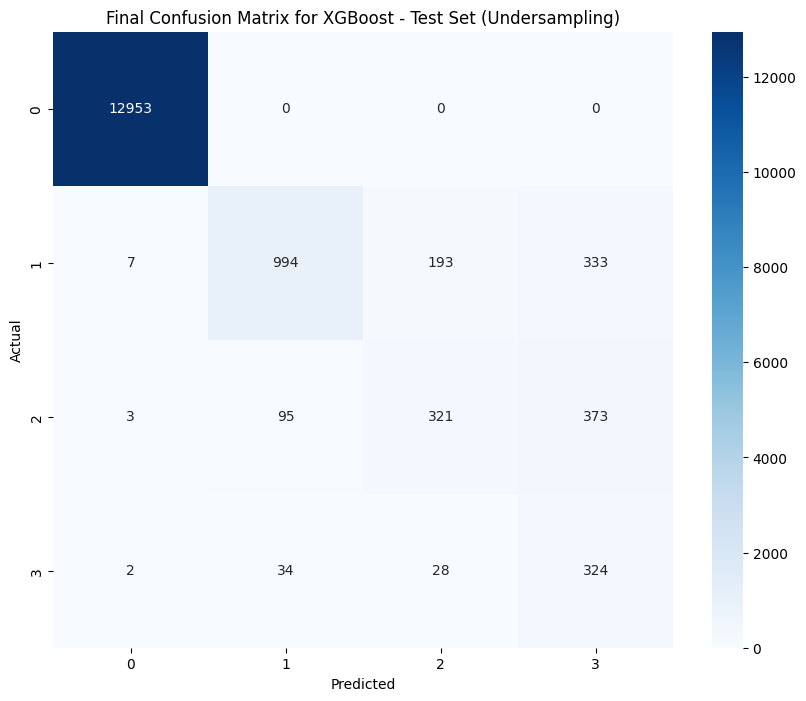

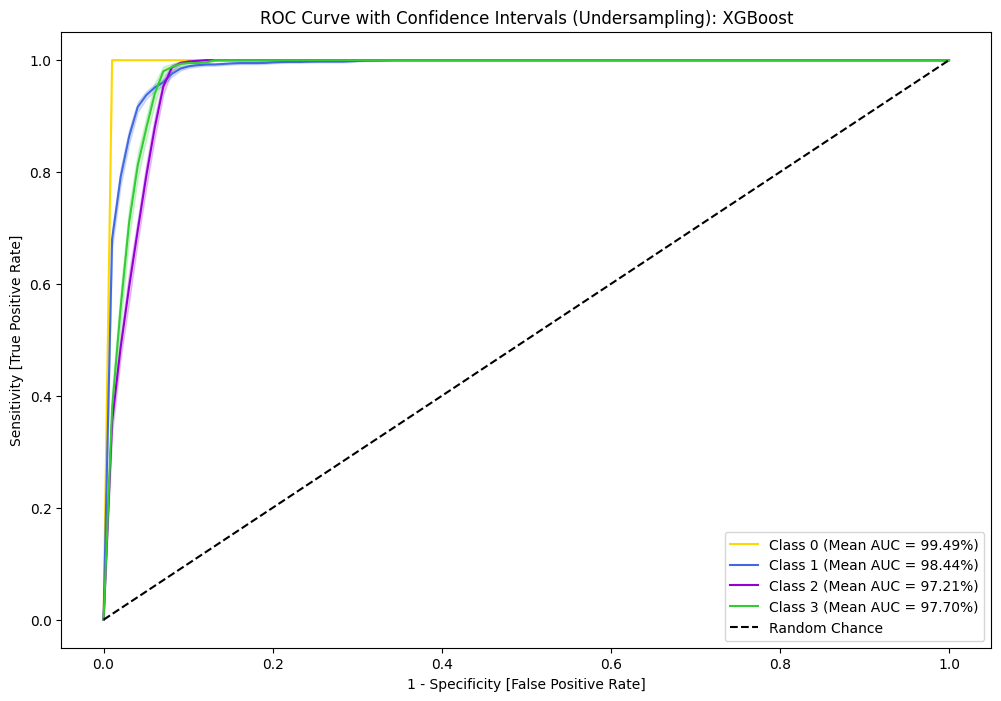


XGBoost train and test predictions have been saved separately.


In [ ]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline  # Import the pipeline from imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

X_train = train_resampled_set.drop(columns=['N_claims_year', 'ID'])
y_train = train_resampled_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year', 'ID'])
y_test = test_set['N_claims_year']

# Define parameter grids for each model
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Updated function with pipeline for undersampling
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Fold {fold} Accuracy: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters (pipeline with undersampling): {search.best_params_}")
    print(f"{model_name} Accuracy on Test Set: {accuracy}")
    print(f"{model_name} F1 Score on Test Set: {f1}")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc}")
    print(f"{model_name} Classification Report:\n{class_report}")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set (Undersampling)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix.png")
    plt.show()

    # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals (Undersampling): {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_undersampling.png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_undersampling_pipe.csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_undersampling_pipe.csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")

    # Save the model
    joblib.dump(best_model, f"{model_name}_best_model.joblib")

    return fold_results, best_model

# Run the nested CV with the XGBoost model as an example
fold_results_xgb, best_model_xgb = nested_cv_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), param_grid_xgb, 'XGBoost', X_train, y_train, X_test, y_test)



Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
2 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\imblearn\pipeline.py", line 326, in fit
    se

  Fold 1 Accuracy: 0.9307151979565773
  Fold 1 F1 Score: 0.9347149506539012
  Fold 1 ROC AUC Score: 0.8533687496521812

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:19:02] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 2 Accuracy: 0.9295178799489144
  Fold 2 F1 Score: 0.9331432566501077
  Fold 2 ROC AUC Score: 0.8499314801606219

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy: 0.9323062185678933
  Fold 4 F1 Score: 0.9362437495919752
  Fold 4 ROC AUC Score: 0.8526732508313745

Fold 5...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:19:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy: 0.9263989782070727
  Fold 5 F1 Score: 0.9306415867567974
  Fold 5 ROC AUC Score: 0.8450490717468527


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:19:30] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
XGBoost Accuracy on Test Set: 0.9318007662835249
XGBoost F1 Score on Test Set: 0.935568786605595
XGBoost ROC AUC Score on Test Set: 0.9843901983130282
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.89      0.65      0.75      1527
           2       0.59      0.41      0.48       792
           3       0.31      0.84      0.46       388

    accuracy                           0.93     15660
   macro avg       0.70      0.72      0.67     15660
weighted avg       0.95      0.93      0.94     15660



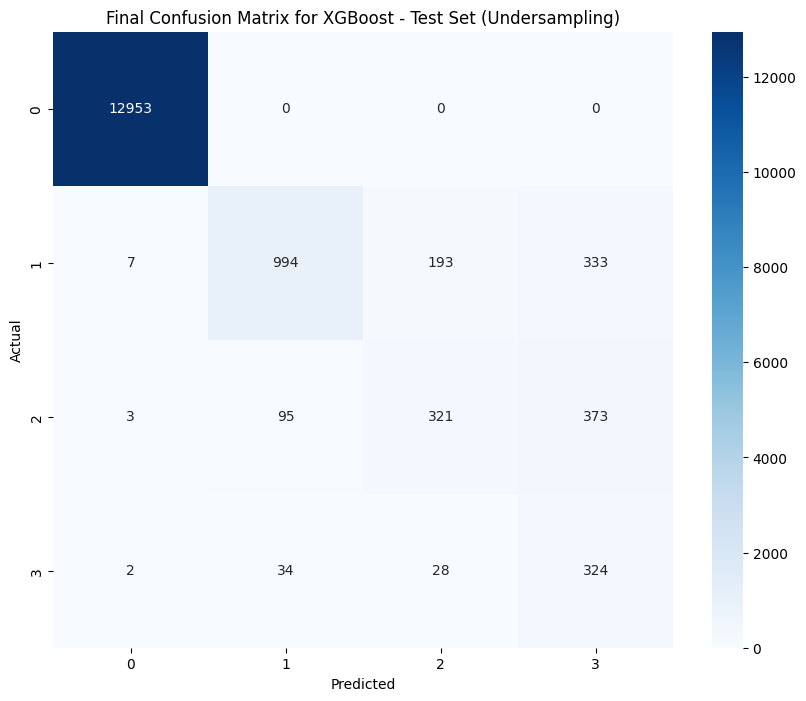

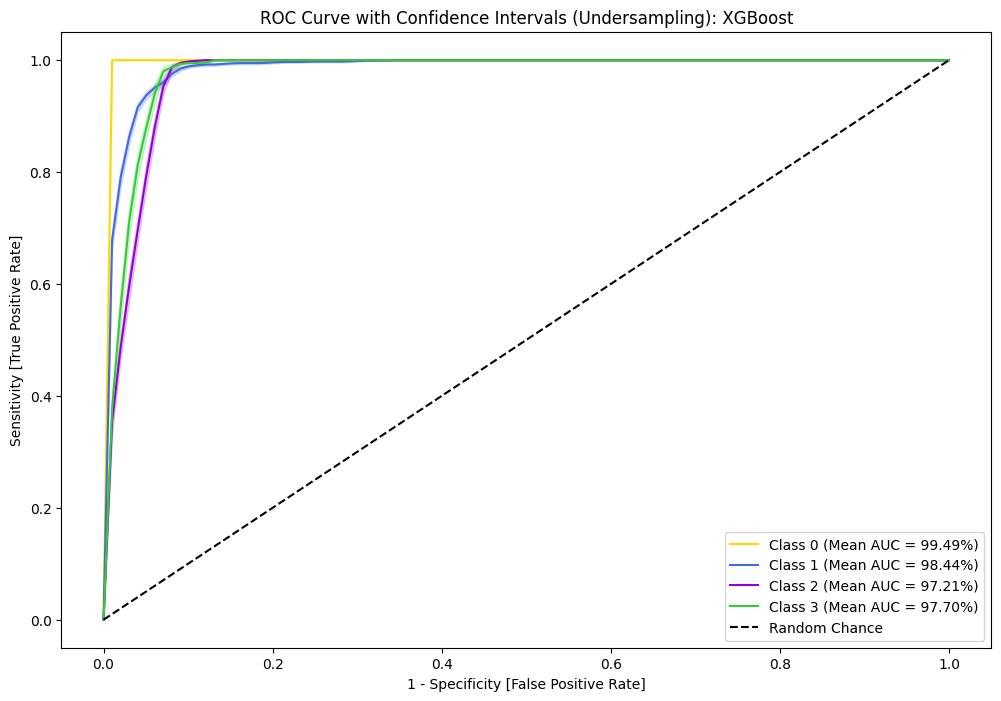

In [2]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline  # Import the pipeline from imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

X_train = train_resampled_set.drop(columns=['N_claims_year', 'ID'])
y_train = train_resampled_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year', 'ID'])
y_test = test_set['N_claims_year']

# Define parameter grids for each model
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Updated function with pipeline for undersampling
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Fold {fold} Accuracy: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters (pipeline with undersampling): {search.best_params_}")
    print(f"{model_name} Accuracy on Test Set: {accuracy}")
    print(f"{model_name} F1 Score on Test Set: {f1}")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc}")
    print(f"{model_name} Classification Report:\n{class_report}")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set (Undersampling)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix.png")
    plt.show()

    # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals (Undersampling): {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_undersampling.png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    # Export separate CSVs for train and test set predictions with ID
    train_df = train_resampled_set[['ID']].copy()  # Retain the 'ID' column from the training set
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = test_set[['ID']].copy()  # Retain the 'ID' column from the test set
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_with_id_undersampling_pipe_2.csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_with_id_undersampling_pipe_2.csv", index=False)

    # Save the model
    joblib.dump(best_model, f"{model_name}_best_model.joblib")

    return fold_results, best_model

# Run the nested CV with the XGBoost model as an example
fold_results_xgb, best_model_xgb = nested_cv_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), param_grid_xgb, 'XGBoost', X_train, y_train, X_test, y_test)


### Tested inner fold for imbalance dataset (using RandomUnderSampler)

In [2]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline  # Import the pipeline from imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib


Starting Nested Cross-Validation for XGBoost...

Outer Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
6 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\imblearn\pipeline.py", line 326, in fit
    se


Inner Fold 1 - Classification Report (for debugging):
              precision    recall  f1-score   support

           0     0.9990    1.0000    0.9995      8290
           1     0.8776    0.6084    0.7186       978
           2     0.5818    0.4427    0.5028       506
           3     0.3328    0.8871    0.4840       248

    accuracy                         0.9309     10022
   macro avg     0.6978    0.7345    0.6762     10022
weighted avg     0.9496    0.9309    0.9343     10022



c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:10:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Inner Fold 2 - Classification Report (for debugging):
              precision    recall  f1-score   support

           0     0.9993    1.0000    0.9996      8290
           1     0.8671    0.6008    0.7098       977
           2     0.5242    0.4280    0.4712       507
           3     0.3118    0.7984    0.4485       248

    accuracy                         0.9272     10022
   macro avg     0.6756    0.7068    0.6573     10022
weighted avg     0.9453    0.9272    0.9310     10022



...


Inner Fold 4 - Classification Report (for debugging):
              precision    recall  f1-score   support

           0     0.9994    1.0000    0.9997      8289
           1     0.8613    0.6295    0.7274       977
           2     0.5899    0.4596    0.5166       507
           3     0.3279    0.8153    0.4677       249

    accuracy                         0.9319     10022
   macro avg     0.6946    0.7261    0.6779     10022
weighted avg     0.9485    0.9319    0.9355     10022



c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:11:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Inner Fold 5 - Classification Report (for debugging):
              precision    recall  f1-score   support

           0     0.9992    1.0000    0.9996      8289
           1     0.9000    0.5890    0.7120       978
           2     0.5700    0.4497    0.5028       507
           3     0.3236    0.8952    0.4754       248

    accuracy                         0.9295     10022
   macro avg     0.6982    0.7335    0.6724     10022
weighted avg     0.9511    0.9295    0.9334     10022

  Outer Fold 5 Accuracy: 0.9246427716133152
  Outer Fold 5 F1 Score: 0.9289150295992572
  Outer Fold 5 ROC AUC Score: 0.8427316778224707


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:11:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
XGBoost Accuracy on Test Set: 0.9318007662835249
XGBoost F1 Score on Test Set: 0.935568786605595
XGBoost ROC AUC Score on Test Set: 0.9843901983130282
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.89      0.65      0.75      1527
           2       0.59      0.41      0.48       792
           3       0.31      0.84      0.46       388

    accuracy                           0.93     15660
   macro avg       0.70      0.72      0.67     15660
weighted avg       0.95      0.93      0.94     15660



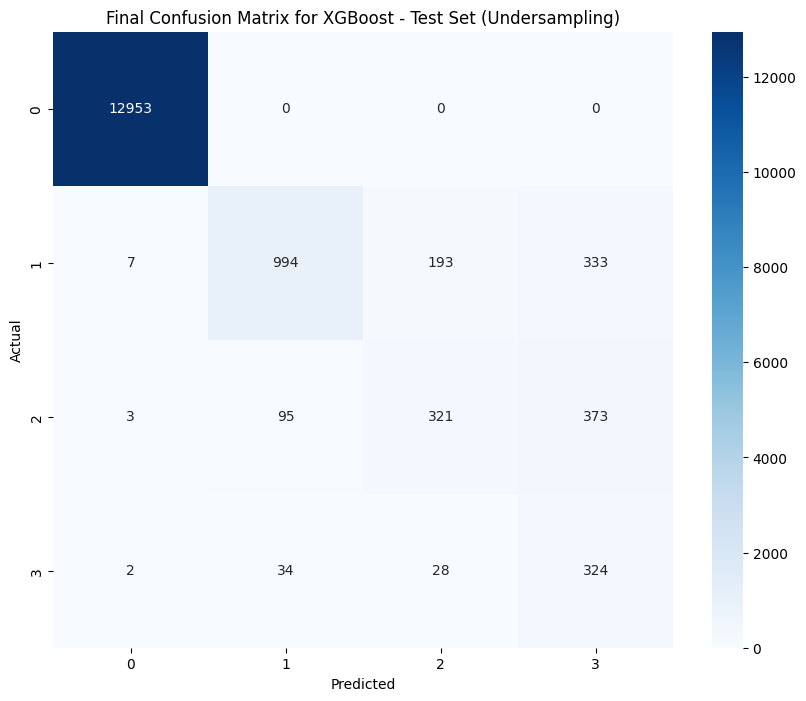

In [4]:
from sklearn.metrics import classification_report
# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

X_train = train_resampled_set.drop(columns=['N_claims_year', 'ID'])
y_train = train_resampled_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year', 'ID'])
y_test = test_set['N_claims_year']

# Define parameter grids for each model
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nOuter Fold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)
        
        # Debugging: Print classification report for each inner fold
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv.split(X_train_fold, y_train_fold), start=1):
            X_inner_train, X_inner_val = X_train_fold.iloc[inner_train_idx], X_train_fold.iloc[inner_val_idx]
            y_inner_train, y_inner_val = y_train_fold.iloc[inner_train_idx], y_train_fold.iloc[inner_val_idx]
            
            # Fit the best model on the inner training data
            best_model = search.best_estimator_
            best_model.fit(X_inner_train, y_inner_train)
            
            # Predict on the inner validation data
            y_inner_pred = best_model.predict(X_inner_val)
            
            # Print classification report for inner validation fold
            print(f"\nInner Fold {inner_fold} - Classification Report (for debugging):")
            print(classification_report(y_inner_val, y_inner_pred, digits=4))

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Outer Fold {fold} Accuracy: {accuracy_fold}")
        print(f"  Outer Fold {fold} F1 Score: {f1_fold}")
        print(f"  Outer Fold {fold} ROC AUC Score: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters (pipeline with undersampling): {search.best_params_}")
    print(f"{model_name} Accuracy on Test Set: {accuracy}")
    print(f"{model_name} F1 Score on Test Set: {f1}")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc}")
    print(f"{model_name} Classification Report:\n{class_report}")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set (Undersampling)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix.png")
    plt.show()

    return fold_results, best_model
fold_results_xgb, best_model_xgb = nested_cv_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), param_grid_xgb, 'XGBoost', X_train, y_train, X_test, y_test)


In [5]:
from collections import Counter

def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nOuter Fold {fold}...")

        # Split data for this outer fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the outer fold's training subset before resampling
        print("Original class distribution in outer fold training subset:", Counter(y_train_fold))

        # Perform inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Inspect the resampled data in the pipeline to confirm the class counts
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv.split(X_train_fold, y_train_fold), start=1):
            X_inner_train, y_inner_train = X_train_fold.iloc[inner_train_idx], y_train_fold.iloc[inner_train_idx]
            
            # Apply undersampling directly to inspect class counts after resampling
            X_resampled, y_resampled = RandomUnderSampler(random_state=42).fit_resample(X_inner_train, y_inner_train)
            print(f"Inner Fold {inner_fold} - Class distribution after undersampling:", Counter(y_resampled))


# Define parameter grid for XGBoost model as an example
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Call the modified nested_cv_model function with XGBoost as an example
from xgboost import XGBClassifier

# Assuming X_train, y_train, X_test, y_test are already defined and loaded
fold_results_xgb, best_model_xgb = nested_cv_model(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid_xgb,
    'XGBoost',
    X_train,
    y_train,
    X_test,
    y_test
)




Starting Nested Cross-Validation for XGBoost...

Outer Fold 1...
Original class distribution in outer fold training subset: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:49:24] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Inner Fold 1 - Class distribution after undersampling: Counter({0: 992, 1: 992, 2: 992, 3: 992})
Inner Fold 2 - Class distribution after undersampling: Counter({0: 992, 1: 992, 2: 992, 3: 992})
Inner Fold 3 - Class distribution after undersampling: Counter({0: 992, 1: 992, 2: 992, 3: 992})
Inner Fold 4 - Class distribution after undersampling: Counter({0: 992, 1: 992, 2: 992, 3: 992})
Inner Fold 5 - Class distribution after undersampling: Counter({0: 992, 1: 992, 2: 992, 3: 992})

Outer Fold 2...
Original class distribution in outer fold training subset: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:49:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Inner Fold 1 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 2 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 3 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 4 - Class distribution after undersampling: Counter({0: 992, 1: 992, 2: 992, 3: 992})
Inner Fold 5 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})

Outer Fold 3...
Original class distribution in outer fold training subset: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:49:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Inner Fold 1 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 2 - Class distribution after undersampling: Counter({0: 992, 1: 992, 2: 992, 3: 992})
Inner Fold 3 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 4 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 5 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})

Outer Fold 5...
Original class distribution in outer fold training subset: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [10:49:42] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Inner Fold 1 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 2 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 3 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})
Inner Fold 4 - Class distribution after undersampling: Counter({0: 992, 1: 992, 2: 992, 3: 992})
Inner Fold 5 - Class distribution after undersampling: Counter({0: 993, 1: 993, 2: 993, 3: 993})


TypeError: cannot unpack non-iterable NoneType object

### GradientBoostingClassifier

In [4]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline  # Import the pipeline from imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

X_train = train_resampled_set.drop(columns=['N_claims_year', 'ID'])
y_train = train_resampled_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year', 'ID'])
y_test = test_set['N_claims_year']

# Define parameter grids for each model
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Updated function with pipeline for undersampling
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Fold {fold} Accuracy: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))
        
    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters (pipeline with undersampling): {search.best_params_}")
    print(f"{model_name} Accuracy on Test Set: {accuracy}")
    print(f"{model_name} F1 Score on Test Set: {f1}")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc}")
    print(f"{model_name} Classification Report:\n{class_report}")

    return fold_results, best_model

# Run the nested CV with the XGBoost model as an example
fold_results_xgb, best_model_xgb = nested_cv_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), param_grid_xgb, 'XGBoost', X_train, y_train, X_test, y_test)



Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:01:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 1 Accuracy: 0.9307151979565773
  Fold 1 F1 Score: 0.9347149506539012
  Fold 1 ROC AUC Score: 0.8533687496521812

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:01:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 2 Accuracy: 0.9295178799489144
  Fold 2 F1 Score: 0.9331432566501077
  Fold 2 ROC AUC Score: 0.8499314801606219

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy: 0.9323062185678933
  Fold 4 F1 Score: 0.9362437495919752
  Fold 4 ROC AUC Score: 0.8526732508313745

Fold 5...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:02:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy: 0.9263989782070727
  Fold 5 F1 Score: 0.9306415867567974
  Fold 5 ROC AUC Score: 0.8450490717468527


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:02:20] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
XGBoost Accuracy on Test Set: 0.9318007662835249
XGBoost F1 Score on Test Set: 0.935568786605595
XGBoost ROC AUC Score on Test Set: 0.9843901983130282
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.89      0.65      0.75      1527
           2       0.59      0.41      0.48       792
           3       0.31      0.84      0.46       388

    accuracy                           0.93     15660
   macro avg       0.70      0.72      0.67     15660
weighted avg       0.95      0.93      0.94     15660



In [ ]:
from collections import Counter

def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nOuter Fold {fold}...")

        # Split data for this outer fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the outer fold's training subset before resampling
        print("Original class distribution in outer fold training subset:", Counter(y_train_fold))

        # Perform inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Inspect the resampled data in the pipeline to confirm the class counts
        for inner_fold, (inner_train_idx, inner_val_idx) in enumerate(inner_cv.split(X_train_fold, y_train_fold), start=1):
            X_inner_train, y_inner_train = X_train_fold.iloc[inner_train_idx], y_train_fold.iloc[inner_train_idx]
            
            # Apply undersampling directly to inspect class counts after resampling
            X_resampled, y_resampled = RandomUnderSampler(random_state=42).fit_resample(X_inner_train, y_inner_train)
            print(f"Inner Fold {inner_fold} - Class distribution after undersampling:", Counter(y_resampled))


In [3]:
pipeline = Pipeline([
    ('under', RandomUnderSampler(random_state=42)),
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
])

# Fit the pipeline on the entire training data
pipeline.fit(X_train, y_train)

# Access the resampled data
X_resampled, y_resampled = pipeline.named_steps['under'].fit_resample(X_train, y_train)
print("Resampled class distribution:", Counter(y_resampled))

c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [11:00:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Resampled class distribution: Counter({0: 1551, 1: 1551, 2: 1551, 3: 1551})



Starting Nested Cross-Validation for Logistic Regression...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy: 0.9183429118773946
  Fold 1 F1 Score: 0.9183518984711635
  Fold 1 ROC AUC Score: 0.7992104841928204

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy: 0.9179438058748404
  Fold 2 F1 Score: 0.9187590826467222
  Fold 2 ROC AUC Score: 0.8008106774285368

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy: 0.9167464878671775
  Fold 3 F1 Score: 0.9185445221553943
  Fold 3 ROC AUC Score: 0.7933588809145332

Fold 4...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy: 0.920491737846252
  Fold 4 F1 Score: 0.9209630415260927
  Fold 4 ROC AUC Score: 0.8094146540144954

Fold 5...
Original class distribution in traini

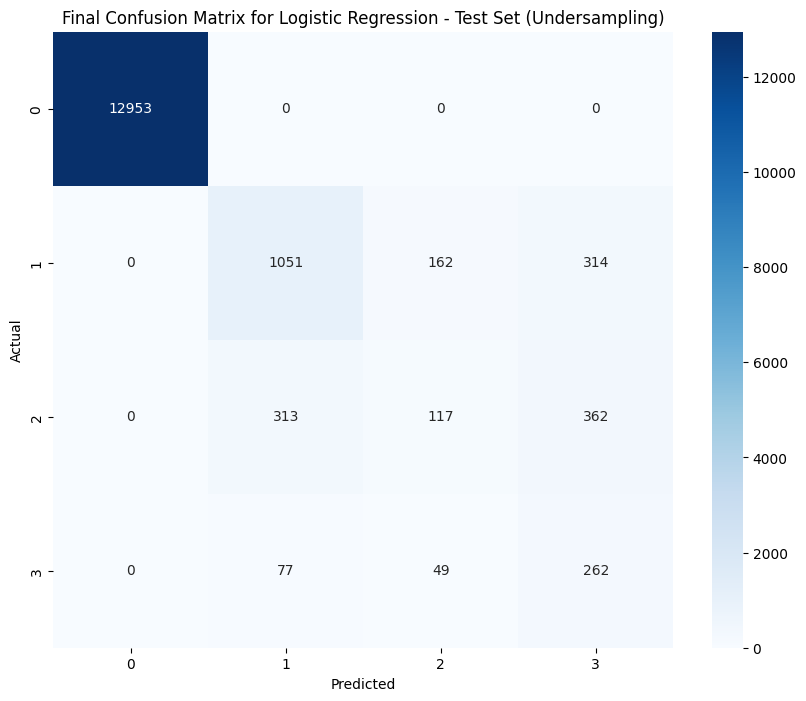

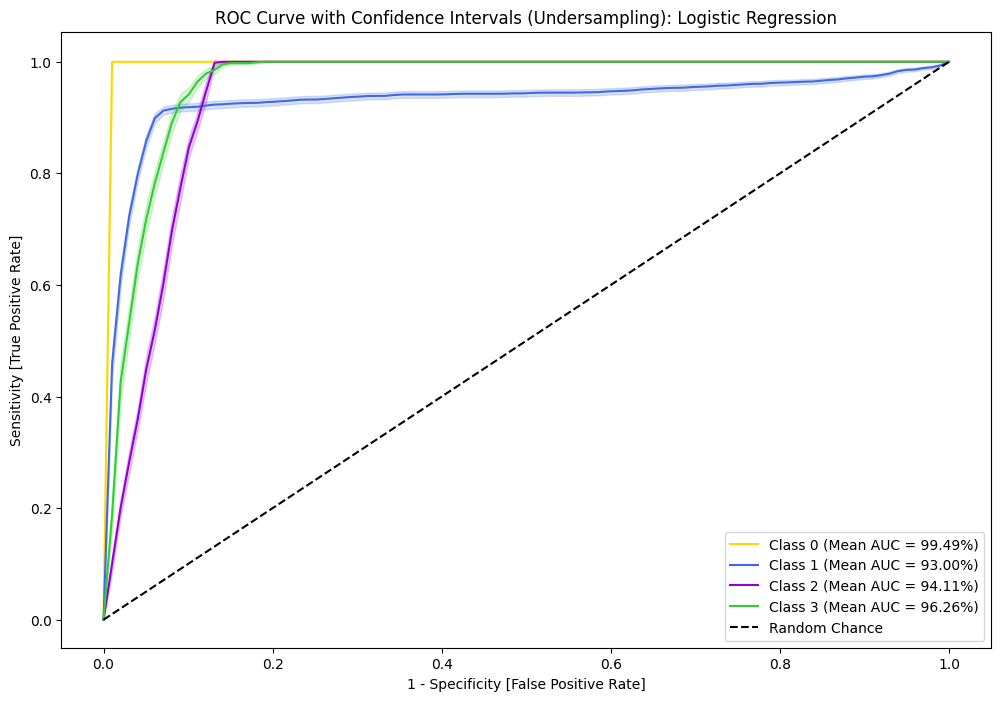


Logistic Regression train and test predictions have been saved separately.


In [ ]:
param_grid_lr = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__max_iter': [100, 200, 500]
}


fold_results_lr, best_model_lr = nested_cv_model(
    LogisticRegression(random_state=42),           # Model for Logistic Regression
    param_grid_lr,                  # Parameter grid for Logistic Regression
    'Logistic Regression',          # Model name
    X_train,                        # Training features
    y_train,                        # Training labels
    X_test,                         # Test features
    y_test                          # Test labels
)

#XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}



Starting Nested Cross-Validation for Random Forest...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy: 0.9271232439335888
  Fold 1 F1 Score: 0.9315093760069243
  Fold 1 ROC AUC Score: 0.8423608876869072

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy: 0.9270434227330779
  Fold 2 F1 Score: 0.9311505291454637
  Fold 2 ROC AUC Score: 0.8429598878427073

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy: 0.9261653895274585
  Fold 3 F1 Score: 0.9302749696393626
  Fold 3 ROC AUC Score: 0.8404697814472262

Fold 4...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy: 0.9279157020834996
  Fold 4 F1 Score: 0.9324348625563493
  Fold 4 ROC AUC Score: 0.842066653204678

Fold 5...
Original class distribution in training fol

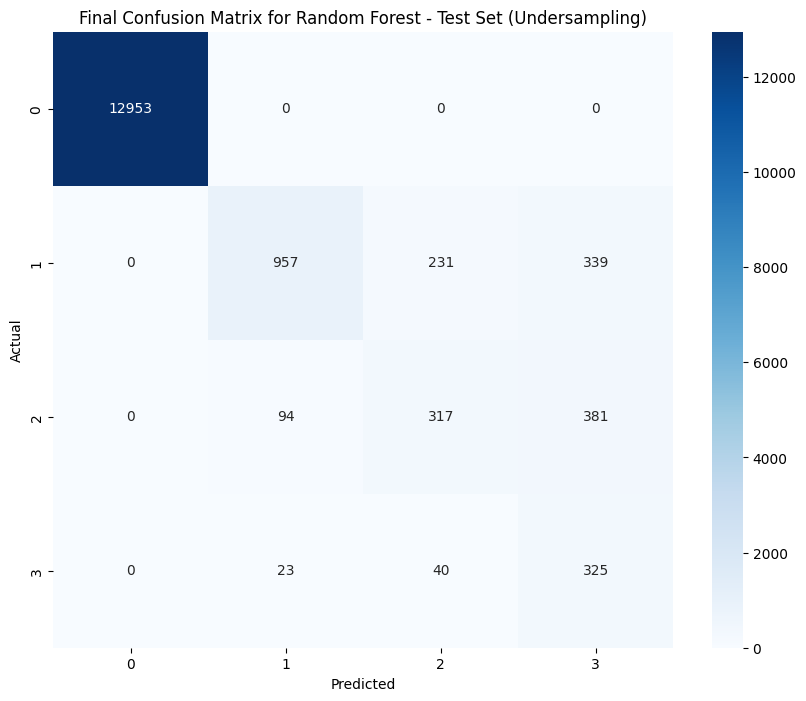

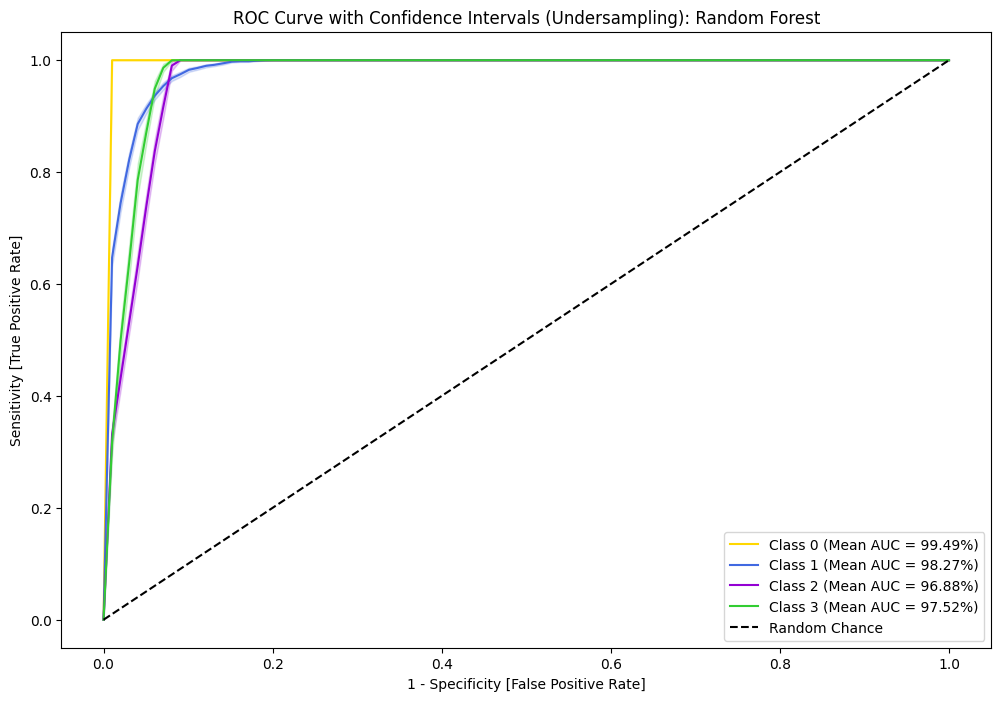


Random Forest train and test predictions have been saved separately.


In [ ]:
param_grid_rf = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 6]
}


fold_results_rf, best_model_rf = nested_cv_model(
    RandomForestClassifier(random_state=42),       # Model for Random Forest
    param_grid_rf,                  # Parameter grid for Random Forest
    'Random Forest',                # Model name
    X_train,                        # Training features
    y_train,                        # Training labels
    X_test,                         # Test features
    y_test                          # Test labels
)




Starting Nested Cross-Validation for Gradient Boosting...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy: 0.9321519795657727
  Fold 1 F1 Score: 0.9359721270657694
  Fold 1 ROC AUC Score: 0.8513941688860432

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy: 0.9293582375478927
  Fold 2 F1 Score: 0.9331130830157928
  Fold 2 ROC AUC Score: 0.8486077251595043

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy: 0.9300766283524904
  Fold 3 F1 Score: 0.9337371532706776
  Fold 3 ROC AUC Score: 0.8468165367985595

Fold 4...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy: 0.9320667358505628
  Fold 4 F1 Score: 0.9358716469910769
  Fold 4 ROC AUC Score: 0.8510959244184939

Fold 5...
Original class distribution in trainin

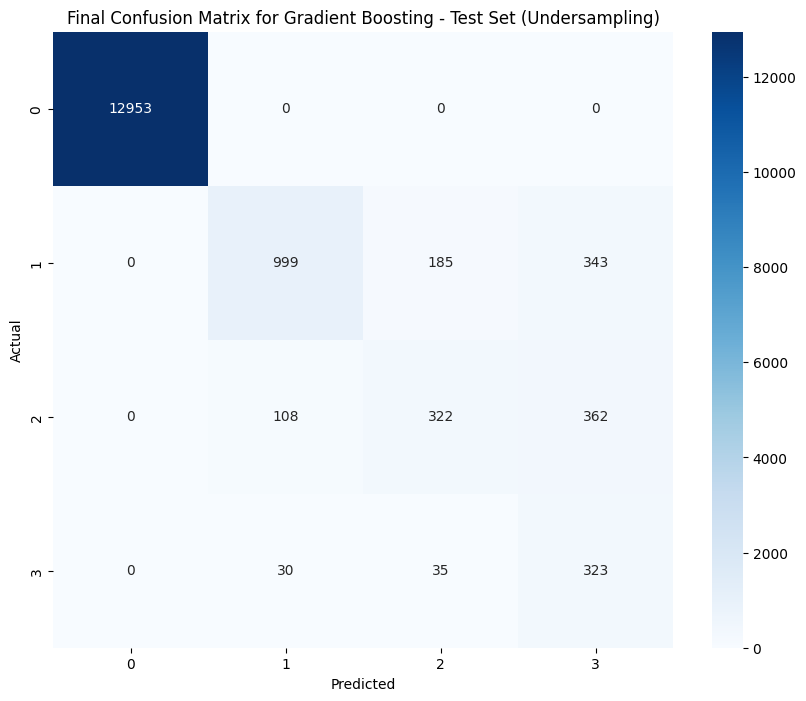

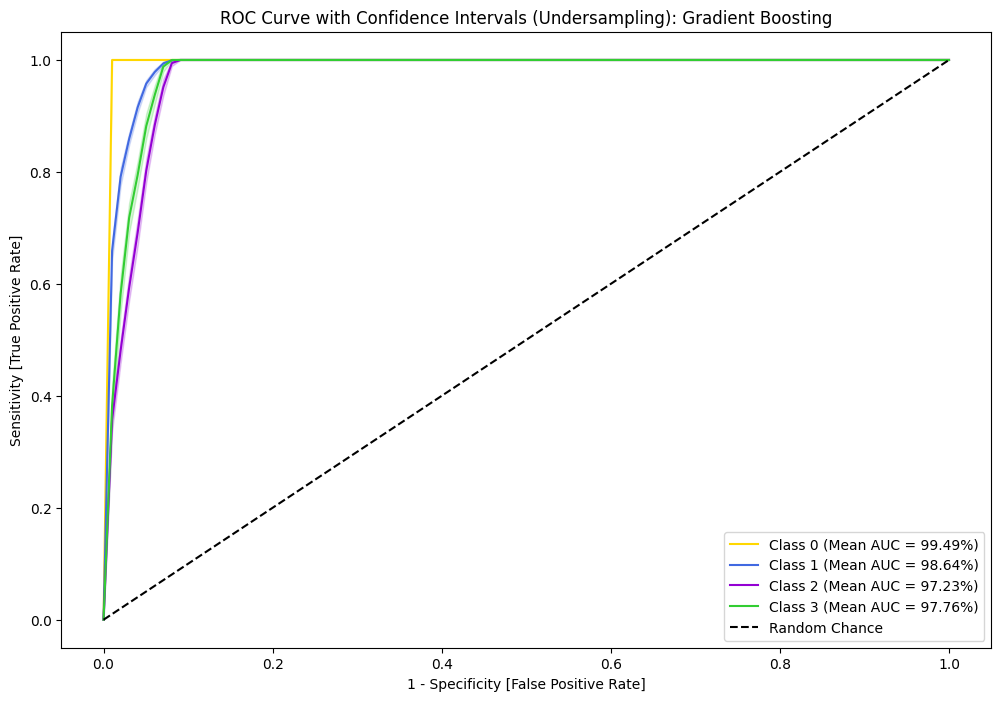


Gradient Boosting train and test predictions have been saved separately.


In [ ]:
param_grid_gb = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.6, 0.7, 0.8, 1.0]
}


fold_results_gb, best_model_gb = nested_cv_model(
    GradientBoostingClassifier(random_state=42),  # Model for Gradient Boosting
    param_grid_gb,                 # Parameter grid for Gradient Boosting
    'Gradient Boosting',            # Model name
    X_train,                        # Training features
    y_train,                        # Training labels
    X_test,                         # Test features
    y_test                          # Test labels
)
#13 mins

#### SHAP

100%|===================| 62637/62640 [12:03<00:00]        

Generating SHAP plots for XGBoost - Class 0...
Generating SHAP plots for XGBoost - Class 1...
Generating SHAP plots for XGBoost - Class 2...
Generating SHAP plots for XGBoost - Class 3...
Generating manual SHAP summary plot for XGBoost - Class 0...
Generating manual SHAP summary plot for XGBoost - Class 1...
Generating manual SHAP summary plot for XGBoost - Class 2...
Generating manual SHAP summary plot for XGBoost - Class 3...


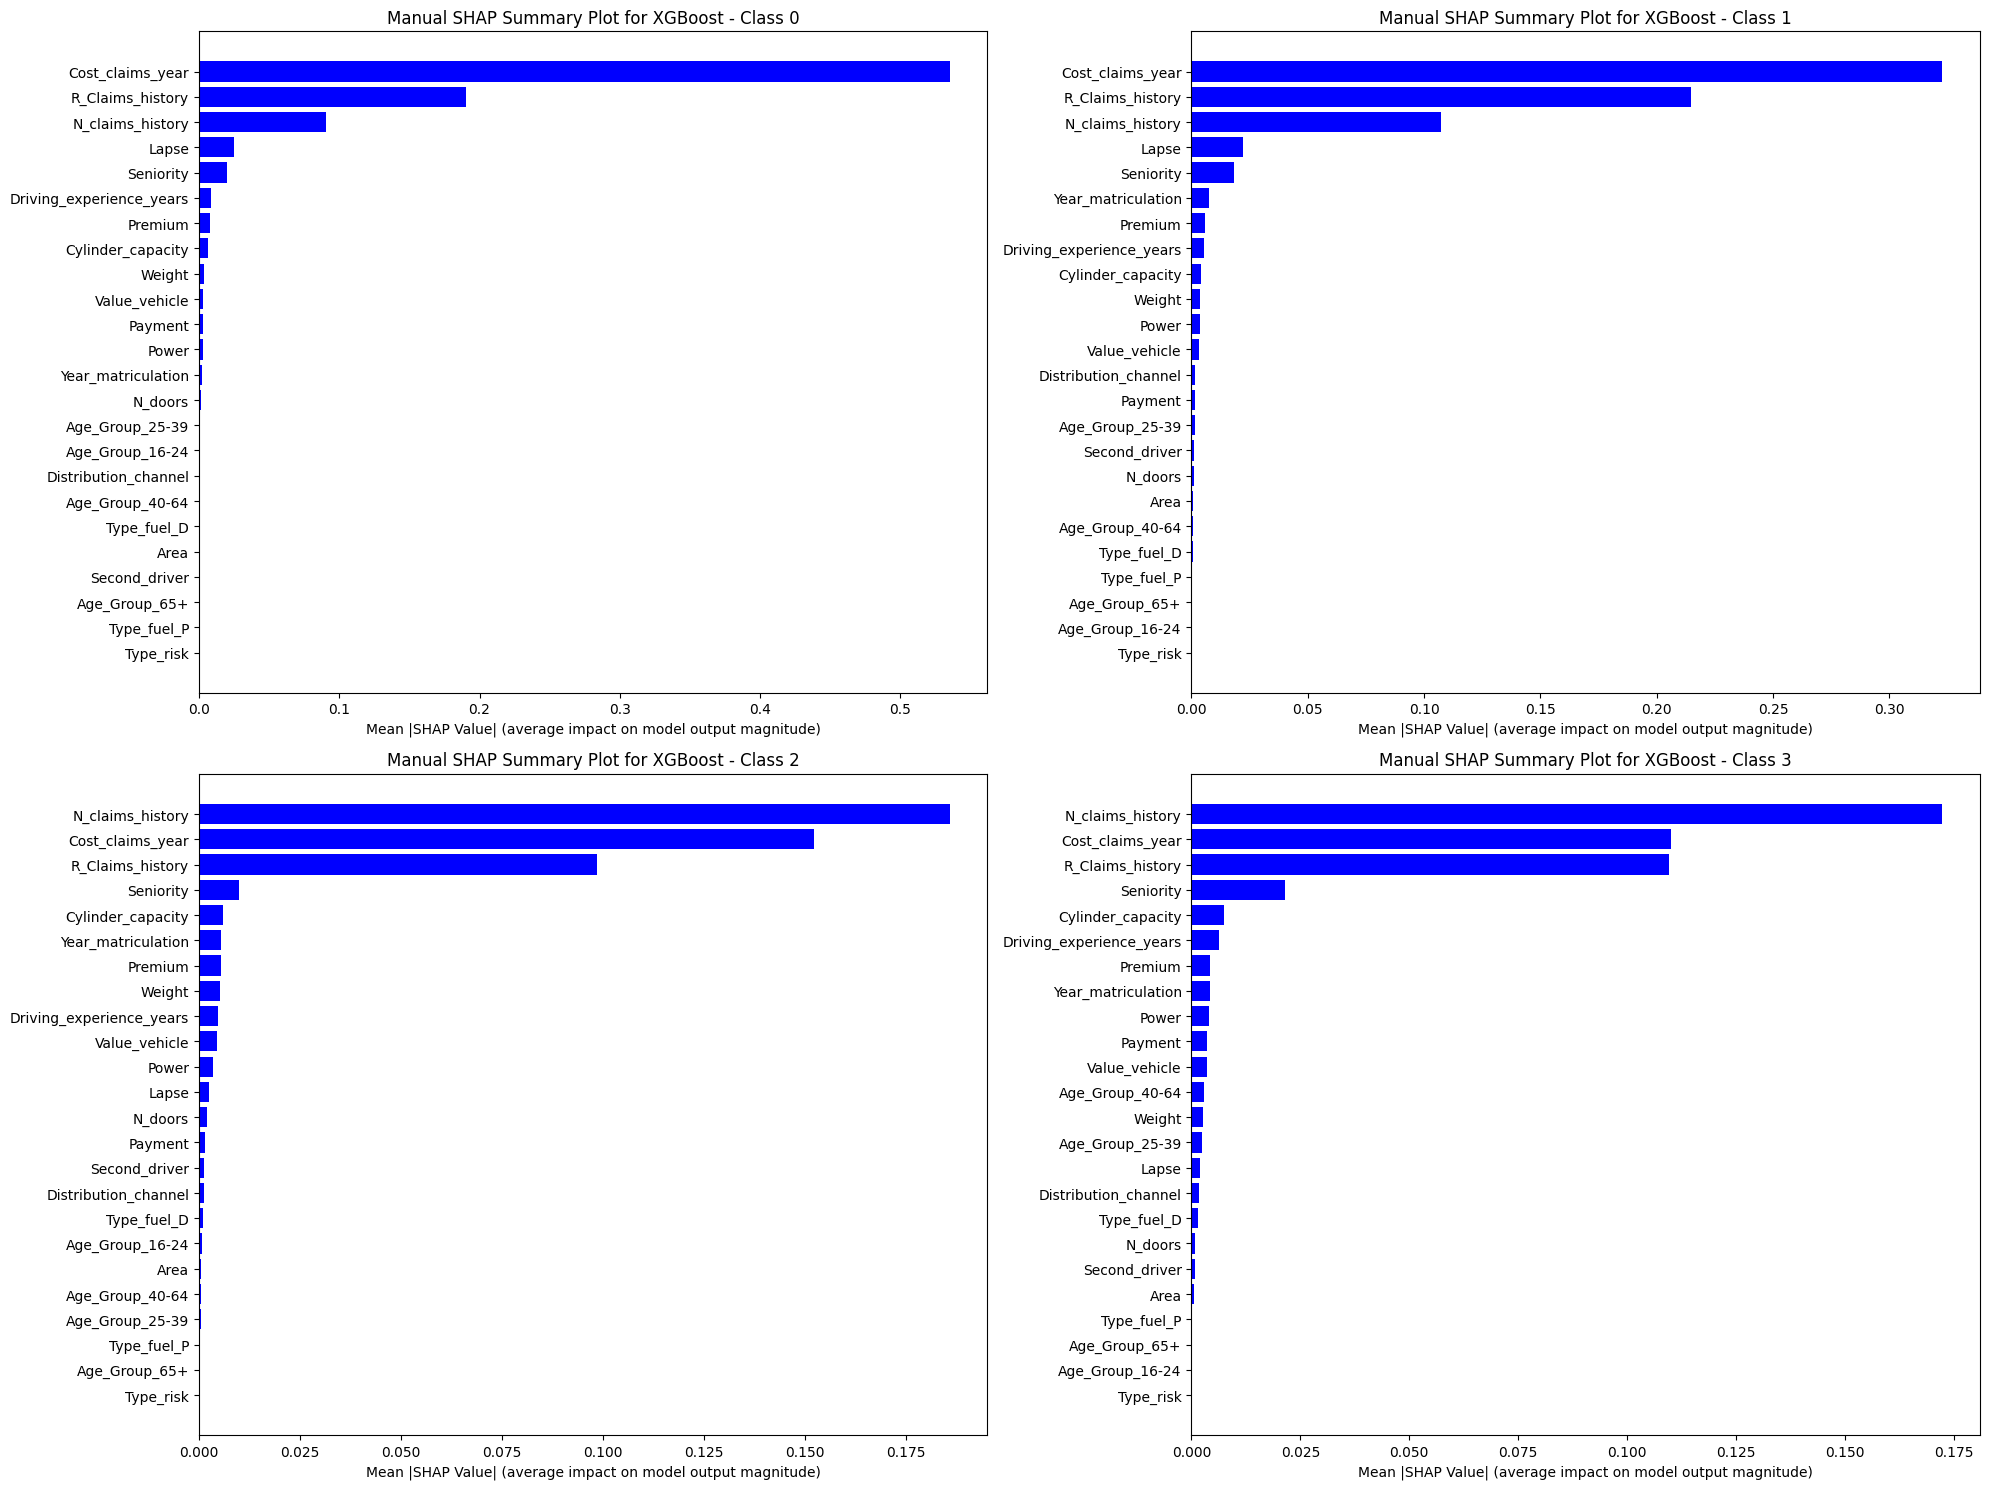

In [17]:
import shap # 13 mins 
import matplotlib.pyplot as plt
import numpy as np


def bee_plot(pipeline, model_name, X_train, X_test, num_classes=4, id_column='ID', random_state=42):
    # Drop the ID column if it exists
    if id_column in X_train.columns:
        X_train = X_train.drop(columns=[id_column])
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Extract the actual model from the pipeline
    model = pipeline.named_steps['model']
    
    # Initialize SHAP explainer and calculate SHAP values
    explainer = shap.Explainer(model, X_train)
    shap_values = explainer(X_test, check_additivity=False)
    
    # Plot SHAP values for each class
    for class_index in range(num_classes):
        print(f"Generating SHAP plots for {model_name} - Class {class_index}...")
        
        # SHAP values for the current class
        shap_values_class = shap_values[..., class_index]
        
        # Save SHAP summary plot
        shap.summary_plot(shap_values_class, X_test, show=False)
        plt.title(f'SHAP Summary Plot for {model_name} - Class {class_index} (undersampling)')
        plt.savefig(f"{model_name}_shap_summary_class_{class_index}_undersampling.png", bbox_inches='tight')
        plt.close()
    
    return shap_values
def summary_shap_plot(shap_values, X_test, model_name, num_classes=4, id_column='ID'):
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Create a single figure for all subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    axes = axes.flatten()

    # Generate manual SHAP summary plots for each class
    for class_index in range(num_classes):
        print(f"Generating manual SHAP summary plot for {model_name} - Class {class_index}...")

        # Extract SHAP values for the current class
        if num_classes > 1:
            shap_values_class = shap_values[..., class_index]
        else:
            shap_values_class = shap_values

        # Calculate mean absolute SHAP values for each feature and sort them
        mean_shap_values = np.abs(shap_values_class.values).mean(axis=0)
        sorted_indices = np.argsort(mean_shap_values)[::-1]  # Sort in descending order

        # Ensure the number of sorted indices does not exceed the number of columns in X_test
        num_features = min(len(sorted_indices), len(X_test.columns))

        # Plot on a specific subplot
        axes[class_index].barh(
            X_test.columns[sorted_indices][:num_features],
            mean_shap_values[sorted_indices][:num_features],
            color='blue'
        )
        axes[class_index].invert_yaxis()  # Invert y-axis to show the most important feature at the top
        axes[class_index].set_xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
        axes[class_index].set_title(f'Manual SHAP Summary Plot for {model_name} - Class {class_index}')

    plt.tight_layout()
    plt.savefig(f"{model_name}_manual_shap_summary_all_classes_undersampling.png", bbox_inches='tight')
    plt.show()
        

# Example Usage
shap_values = bee_plot(best_model_xgb, 'XGBoost', X_train, X_test, random_state=42)
summary_shap_plot(shap_values, X_test, 'XGBoost')




In [18]:
import shap  # 3 mins
import matplotlib.pyplot as plt
import numpy as np

def bee_plot(pipeline, model_name, X_train, X_test, num_classes=4, id_column='ID', random_state=42):
    # Drop the ID column if it exists
    if id_column in X_train.columns:
        X_train = X_train.drop(columns=[id_column])
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Extract the actual model from the pipeline
    model = pipeline.named_steps['model']
    
    # Create SHAP explainer for the tree model (Random Forest)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer(X_test, check_additivity=False)  # Disable additivity check if needed
    
    # Generate SHAP plots for each class and save them
    for class_index in range(num_classes):
        print(f"Generating SHAP plots for {model_name} - Class {class_index}...")
        
        # Extract SHAP values for the current class
        shap_values_class = shap_values[..., class_index] if num_classes > 1 else shap_values
        
        # Generate and save the SHAP summary plot
        shap.summary_plot(shap_values_class, X_test, show=False)
        plt.title(f'SHAP Summary Plot for {model_name} - Class {class_index} (undersampling)')
        plt.savefig(f"{model_name}_shap_summary_class_{class_index}_undersampling.png", bbox_inches='tight')
        plt.close()
    
    return shap_values  # Return SHAP values for further use

def summary_shap_plot(shap_values, X_test, model_name, num_classes=4, id_column='ID'):
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Generate manual SHAP summary plots for each class
    for class_index in range(num_classes):
        print(f"Generating manual SHAP summary plot for {model_name} - Class {class_index}...")

        # Extract SHAP values for the current class
        shap_values_class = shap_values[..., class_index] if num_classes > 1 else shap_values

        # Calculate mean absolute SHAP values for each feature and sort them
        mean_shap_values = np.abs(shap_values_class.values).mean(axis=0)
        sorted_indices = np.argsort(mean_shap_values)[::-1]  # Sort in descending order

        # Ensure the number of sorted indices does not exceed the number of columns in X_test
        num_features = min(len(sorted_indices), len(X_test.columns))

        plt.figure(figsize=(12, 8))
        plt.barh(
            X_test.columns[sorted_indices][:num_features],
            mean_shap_values[sorted_indices][:num_features],
            color='blue'
        )
        plt.xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
        plt.title(f'Manual SHAP Summary Plot for {model_name} - Class {class_index} (undersampling)')
        plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
        
        # Save the plot as a PNG file
        plt.savefig(f"{model_name}_manual_shap_summary_class_{class_index}_undersampling.png", bbox_inches='tight')
        plt.close()

# Run bee_plot to get SHAP values for the Random Forest model
shap_values_rf = bee_plot(best_model_rf, 'RandomForest', X_train, X_test, random_state=42)

# Use the SHAP values for the summary plots
summary_shap_plot(shap_values_rf, X_test, 'RandomForest')


Generating SHAP plots for RandomForest - Class 0...
Generating SHAP plots for RandomForest - Class 1...
Generating SHAP plots for RandomForest - Class 2...
Generating SHAP plots for RandomForest - Class 3...
Generating manual SHAP summary plot for RandomForest - Class 0...
Generating manual SHAP summary plot for RandomForest - Class 1...
Generating manual SHAP summary plot for RandomForest - Class 2...
Generating manual SHAP summary plot for RandomForest - Class 3...


                     Feature  Overall_Mean_Importance
5           Cost_claims_year                 0.236944
6           N_claims_history                 0.068203
7           R_Claims_history                 0.064845
1                  Seniority                 0.007762
2                      Lapse                 0.005455
17  Driving_experience_years                 0.002909
4                    Premium                 0.002832
3                    Payment                 0.002789
14             Value_vehicle                 0.001850
13         Cylinder_capacity                 0.001811
16                    Weight                 0.001809
11        Year_matriculation                 0.001758
12                     Power                 0.001712
0       Distribution_channel                 0.001358
20           Age_Group_40-64                 0.000889
15                   N_doors                 0.000774
9                       Area                 0.000648
23               Type_fuel_P

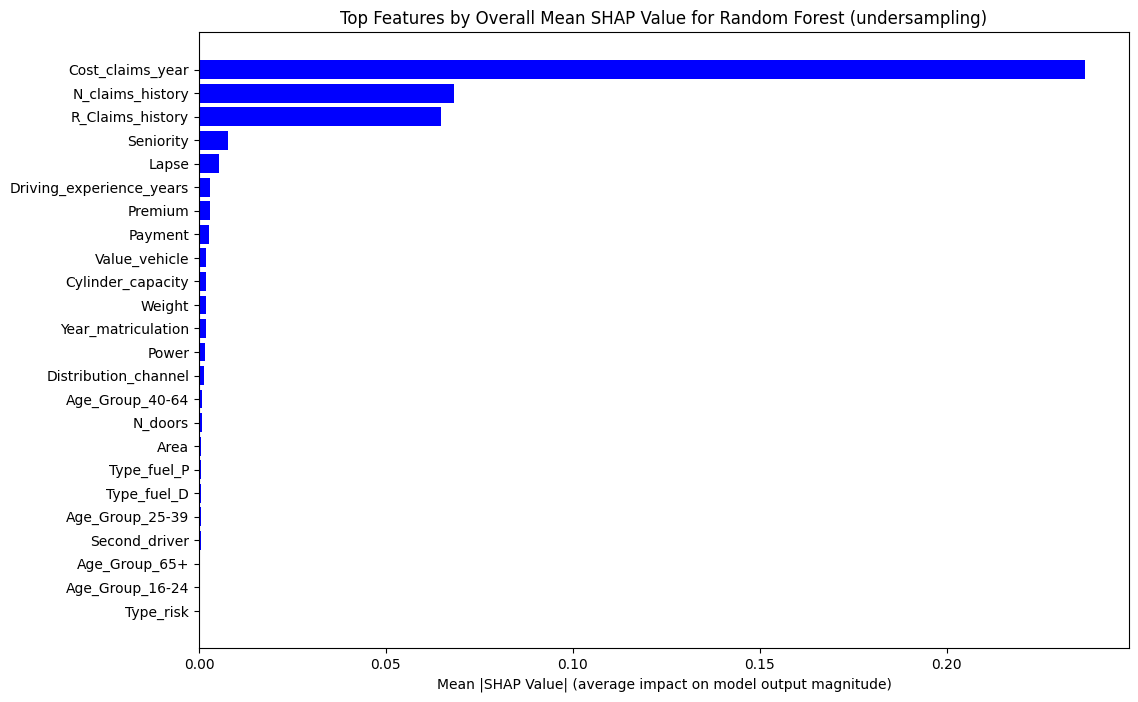

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_and_plot_overall_mean_shap_values(shap_values, X_test, model_name, num_classes=4, id_column='ID'):
    """
    Calculate mean SHAP values for each feature across all classes and plot the top features.
    
    Parameters:
    shap_values (shap._explanation.Explanation): SHAP values output from the explainer.
    X_test (pd.DataFrame): Test dataset to match feature names.
    model_name (str): Name of the model for plot labeling.
    num_classes (int): Number of classes in the multi-class classification.
    id_column (str): Column name to be dropped if present.
    
    Returns:
    pd.DataFrame: DataFrame of features sorted by overall mean SHAP importance.
    """
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])

    # Check if the number of features matches between shap_values and X_test
    num_features_shap = shap_values[..., 0].values.shape[1]  # Number of features in SHAP values
    num_features_test = X_test.shape[1]  # Number of features in X_test

    if num_features_shap != num_features_test:
        print(f"Warning: Number of features in SHAP values ({num_features_shap}) does not match number of features in X_test ({num_features_test}).")
        return None
    
    # Initialize a DataFrame to store mean absolute SHAP values for each feature and class
    feature_importance_df = pd.DataFrame()
    
    # Calculate mean absolute SHAP values for each class
    for class_index in range(num_classes):
        class_shap_values = shap_values[..., class_index].values  # Get SHAP values for the current class
        mean_abs_shap = np.abs(class_shap_values).mean(axis=0)  # Mean absolute SHAP value for each feature
        feature_importance_df[f'Class_{class_index}'] = mean_abs_shap
    
    # Add feature names from X_test
    feature_importance_df['Feature'] = X_test.columns[:num_features_shap]  # Match feature count

    # Calculate overall mean SHAP value across all classes for each feature
    feature_importance_df['Overall_Mean_Importance'] = feature_importance_df.iloc[:, :-1].mean(axis=1)
    
    # Sort features by overall mean importance
    feature_importance_df = feature_importance_df.sort_values(by='Overall_Mean_Importance', ascending=False)
    
    # Display the top features
    top_features = feature_importance_df[['Feature', 'Overall_Mean_Importance']]
    print(top_features)
    
    # Plot the top features
    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Overall_Mean_Importance'], color='blue')
    plt.xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
    plt.title(f'Top Features by Overall Mean SHAP Value for {model_name} (undersampling)')
    plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
    plt.show()
    
    return feature_importance_df

# Example usage to calculate overall mean SHAP values and plot the results
overall_feature_importance_df = calculate_and_plot_overall_mean_shap_values(shap_values_rf, X_test, "Random Forest", num_classes=4)


                     Feature  Overall_Mean_Importance
5           Cost_claims_year                 0.280104
7           R_Claims_history                 0.153252
6           N_claims_history                 0.139056
1                  Seniority                 0.017404
2                      Lapse                 0.012937
17  Driving_experience_years                 0.006239
13         Cylinder_capacity                 0.006097
4                    Premium                 0.005777
11        Year_matriculation                 0.004866
16                    Weight                 0.003839
14             Value_vehicle                 0.003502
12                     Power                 0.003432
3                    Payment                 0.002376
0       Distribution_channel                 0.001336
19           Age_Group_25-39                 0.001332
15                   N_doors                 0.001271
20           Age_Group_40-64                 0.001193
10             Second_driver

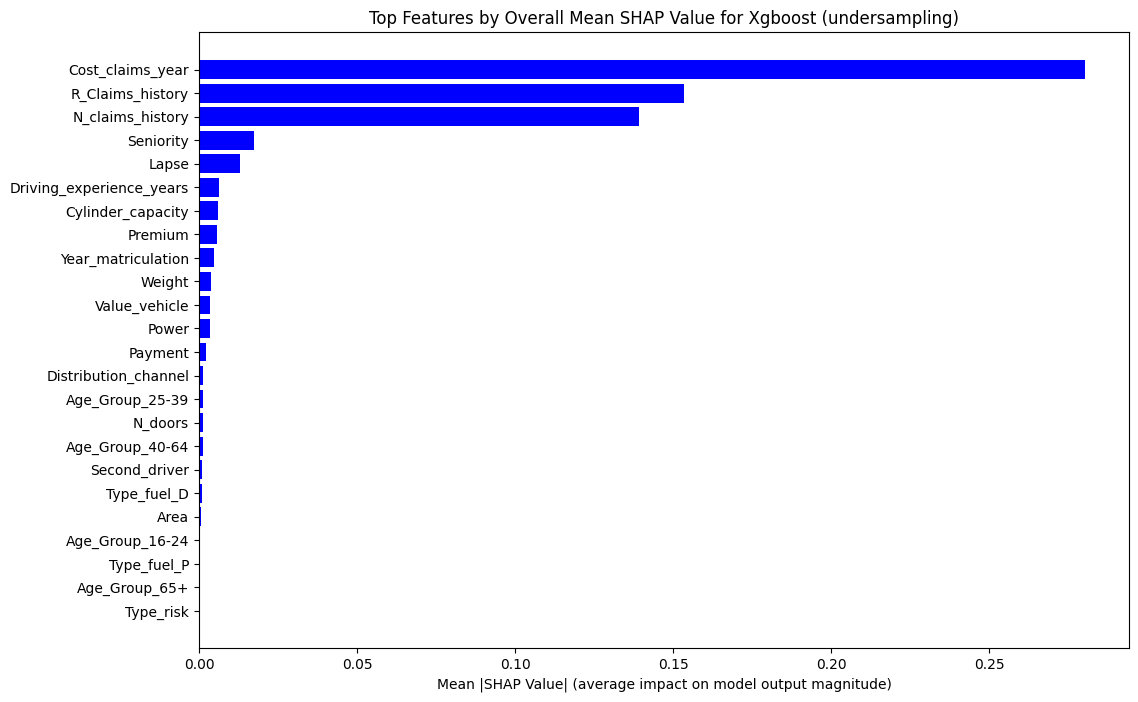

In [20]:
overall_feature_importance_df = calculate_and_plot_overall_mean_shap_values(shap_values, X_test, "Xgboost", num_classes=4)

In [50]:
import shap
import matplotlib.pyplot as plt
import numpy as np

def bee_plot(pipeline, model_name, X_train, X_test, num_classes=4, id_column='ID', random_state=42):
    # Drop the ID column if it exists
    if id_column in X_train.columns:
        X_train = X_train.drop(columns=[id_column])
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Extract the actual model from the pipeline
    model = pipeline.named_steps['model']
    
    # Dynamically select the appropriate SHAP explainer
    if hasattr(model, 'coef_'):
        # For linear models like Logistic Regression
        explainer = shap.LinearExplainer(model, X_train)
        shap_values = explainer.shap_values(X_test)
    else:
        # For tree-based models like Random Forest
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test, check_additivity=False)
    
    # Generate SHAP plots for each class and save them
    for class_index in range(num_classes):
        print(f"Generating SHAP plots for {model_name} - Class {class_index}...")

        # Handle SHAP values for the current class
        if num_classes > 1 and hasattr(model, 'coef_'):
            shap_values_class = shap_values[class_index]  # Multi-class case for Logistic Regression
        else:
            shap_values_class = shap_values  # Single-class case or tree-based model

        # Ensure shap_values_class has the correct shape for X_test
        if len(shap_values_class.shape) > 2:  # If extra dimensions exist
            shap_values_class = shap_values_class[:, :X_test.shape[1]]

        # Generate and save the SHAP summary plot
        shap.summary_plot(shap_values_class, X_test, show=False)
        plt.title(f'SHAP Summary Plot for {model_name} - Class {class_index} (undersampling)')
        plt.savefig(f"{model_name}_shap_summary_class_{class_index}_undersampling.png", bbox_inches='tight')
        plt.close()
    
    return shap_values  # Return SHAP values for further use

def summary_shap_plot(shap_values, X_test, model_name, num_classes=4, id_column='ID'):
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])
    
    # Generate manual SHAP summary plots for each class
    for class_index in range(num_classes):
        print(f"Generating manual SHAP summary plot for {model_name} - Class {class_index}...")

        # Extract SHAP values for the current class
        if num_classes > 1:
            shap_values_class = shap_values[class_index]  # Multi-class
        else:
            shap_values_class = shap_values  # Single-class

        # Calculate mean absolute SHAP values for each feature and sort them
        mean_shap_values = np.abs(shap_values_class).mean(axis=0)
        sorted_indices = np.argsort(mean_shap_values)[::-1]  # Sort in descending order

        # Ensure the number of sorted indices does not exceed the number of columns in X_test
        num_features = min(len(sorted_indices), len(X_test.columns))

        plt.figure(figsize=(12, 8))
        plt.barh(
            X_test.columns[sorted_indices][:num_features],
            mean_shap_values[sorted_indices][:num_features],
            color='blue'
        )
        plt.xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
        plt.title(f'Manual SHAP Summary Plot for {model_name} - Class {class_index} (undersampling)')
        plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
        
        # Save the plot as a PNG file
        plt.savefig(f"{model_name}_manual_shap_summary_class_{class_index}_undersampling.png", bbox_inches='tight')
        plt.close()

# Example usage:
# bee_plot to get SHAP values for the Logistic Regression model
shap_values_lr = bee_plot(best_model_lr, 'LogisticRegression', X_train, X_test, random_state=42)

# Use the SHAP values for the summary plots
summary_shap_plot(shap_values_lr, X_test, 'LogisticRegression')


Generating SHAP plots for LogisticRegression - Class 0...


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

In [51]:
shap_values_gb = bee_plot(best_model_gb, 'Gradient Boosting', X_train, X_test, random_state=42)

# Use the SHAP values for the summary plots
summary_shap_plot(shap_values_gb, X_test, 'Gradient Boosting')

InvalidModelError: GradientBoostingClassifier is only supported for binary classification right now!

                     Feature  Overall_Mean_Importance
5           Cost_claims_year                 0.258524
7           R_Claims_history                 0.109048
6           N_claims_history                 0.103630
1                  Seniority                 0.012583
2                      Lapse                 0.009196
17  Driving_experience_years                 0.004574
4                    Premium                 0.004305
13         Cylinder_capacity                 0.003954
11        Year_matriculation                 0.003312
16                    Weight                 0.002824
14             Value_vehicle                 0.002676
3                    Payment                 0.002583
12                     Power                 0.002572
0       Distribution_channel                 0.001347
20           Age_Group_40-64                 0.001041
15                   N_doors                 0.001023
19           Age_Group_25-39                 0.000965
22               Type_fuel_D

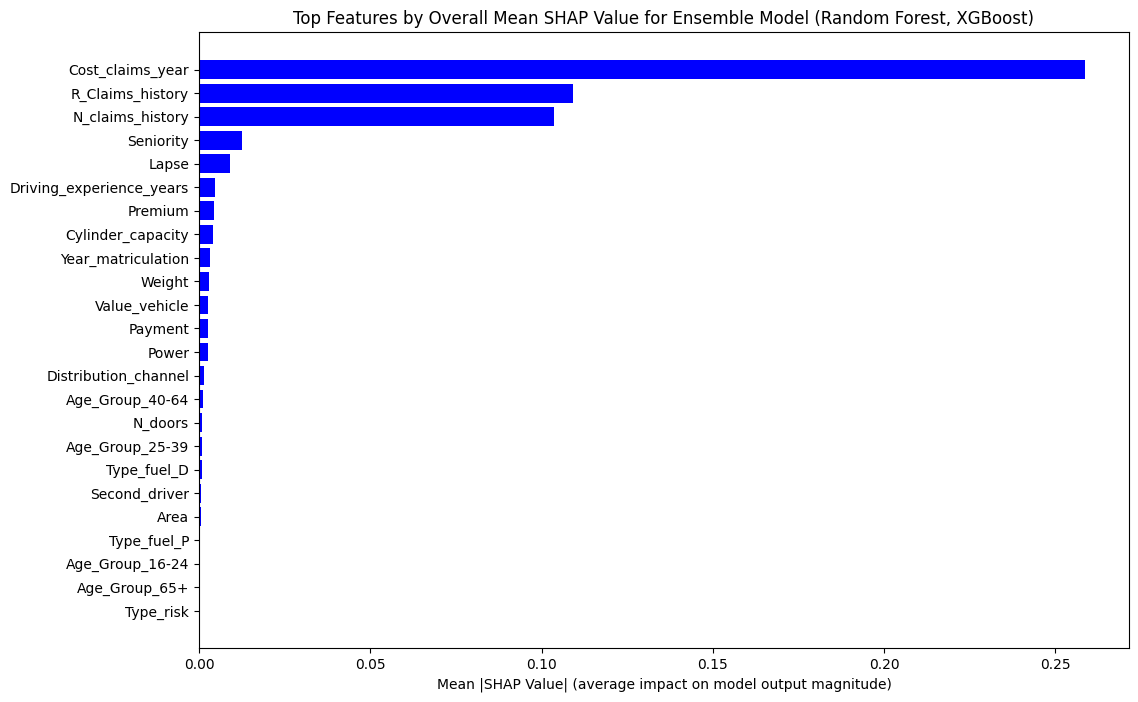

In [ ]:
#mean of both rf and xg
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

def calculate_and_plot_overall_mean_shap_values(shap_values_list, X_test, model_names, num_classes=4, id_column='ID'):
    """
    Calculate mean SHAP values for each feature across all classes and plot the top features.
    Allows for combining SHAP values from multiple models by averaging.

    Parameters:
    shap_values_list (list): List of SHAP values output from explainers for multiple models.
    X_test (pd.DataFrame): Test dataset to match feature names.
    model_names (list): List of model names for plot labeling.
    num_classes (int): Number of classes in the multi-class classification.
    id_column (str): Column name to be dropped if present.

    Returns:
    pd.DataFrame: DataFrame of features sorted by overall mean SHAP importance.
    """
    # Drop the ID column from the test set if it exists
    if id_column in X_test.columns:
        X_test = X_test.drop(columns=[id_column])

    # Initialize a DataFrame to store mean absolute SHAP values for each feature and class
    feature_importance_df = pd.DataFrame()

    # Calculate mean absolute SHAP values across models
    for class_index in range(num_classes):
        combined_shap_values = np.zeros(X_test.shape[1])
        
        # Iterate over each model's SHAP values
        for shap_values in shap_values_list:
            # Ensure shap_values has the correct number of features
            if shap_values[..., class_index].values.shape[1] != X_test.shape[1]:
                raise ValueError(f"Mismatch in features between SHAP values and X_test for class {class_index}.")
            
            # Accumulate SHAP values for each class
            combined_shap_values += np.abs(shap_values[..., class_index].values).mean(axis=0)

        # Average across all models
        mean_abs_shap = combined_shap_values / len(shap_values_list)
        feature_importance_df[f'Class_{class_index}'] = mean_abs_shap
    
    # Add feature names from X_test
    feature_importance_df['Feature'] = X_test.columns
    
    # Calculate overall mean SHAP value across all classes for each feature
    feature_importance_df['Overall_Mean_Importance'] = feature_importance_df.iloc[:, :-1].mean(axis=1)
    
    # Sort features by overall mean importance
    feature_importance_df = feature_importance_df.sort_values(by='Overall_Mean_Importance', ascending=False)
    
    # Display the top features
    top_features = feature_importance_df[['Feature', 'Overall_Mean_Importance']]
    print(top_features)
    
    # Plot the top features
    plt.figure(figsize=(12, 8))
    plt.barh(top_features['Feature'], top_features['Overall_Mean_Importance'], color='blue')
    plt.xlabel('Mean |SHAP Value| (average impact on model output magnitude)')
    plt.title(f'Top Features by Overall Mean SHAP Value for Ensemble Model ({", ".join(model_names)})')
    plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
    plt.show()
    
    return feature_importance_df

# Example usage
# shap_values_rf = explainer_rf.shap_values(X_test)  # SHAP values for Random Forest
# shap_values_xg = explainer_xg.shap_values(X_test)  # SHAP values for XGBoost

# Assuming shap_values_rf and shap_values_xg are lists of SHAP values for each class
shap_values_list = [shap_values_rf, shap_values]
model_names = ["Random Forest", "XGBoost"]
overall_feature_importance_df = calculate_and_plot_overall_mean_shap_values(shap_values_list, X_test, model_names, num_classes=4)


#### SHAP_feature_Selection 


Starting Nested Cross-Validation for Logistic Regression...

Fold 1...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 1 Accuracy_shap_undersampling: 0.9176245210727969
  Fold 1 F1 Score_shap_undersampling: 0.9168889545292852
  Fold 1 ROC AUC Score_shap_undersampling: 0.7821187135436259

Fold 2...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 2 Accuracy_shap_undersampling: 0.9240102171136654
  Fold 2 F1 Score_shap_undersampling: 0.9225307030409924
  Fold 2 ROC AUC Score_shap_undersampling: 0.794412235500792

Fold 3...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 5 Accuracy_shap_undersampling: 0.9168994970862936
  Fold 5 F1 Score_shap_undersampling: 0.9153768098759282
  Fold 5 ROC AUC Score_shap_undersampling: 0.7855641591579584


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Best Parameters: {'model__solver': 'lbfgs', 'model__max_iter': 500, 'model__C': 0.1} (SHAP_undersampling)
Logistic Regression Accuracy on Test Set: 0.9210089399744572 (SHAP_undersampling)
Logistic Regression F1 Score on Test Set: 0.9175744909085956 (SHAP_undersampling)
Logistic Regression ROC AUC Score on Test Set: 0.9711728877652666 (SHAP_undersampling)
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.67      0.75      0.71      1527
           2       0.42      0.18      0.25       792
           3       0.28      0.48      0.35       388

    accuracy                           0.92     15660
   macro avg       0.59      0.60      0.58     15660
weighted avg       0.92      0.92      0.92     15660
 (SHAP_undersampling)


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


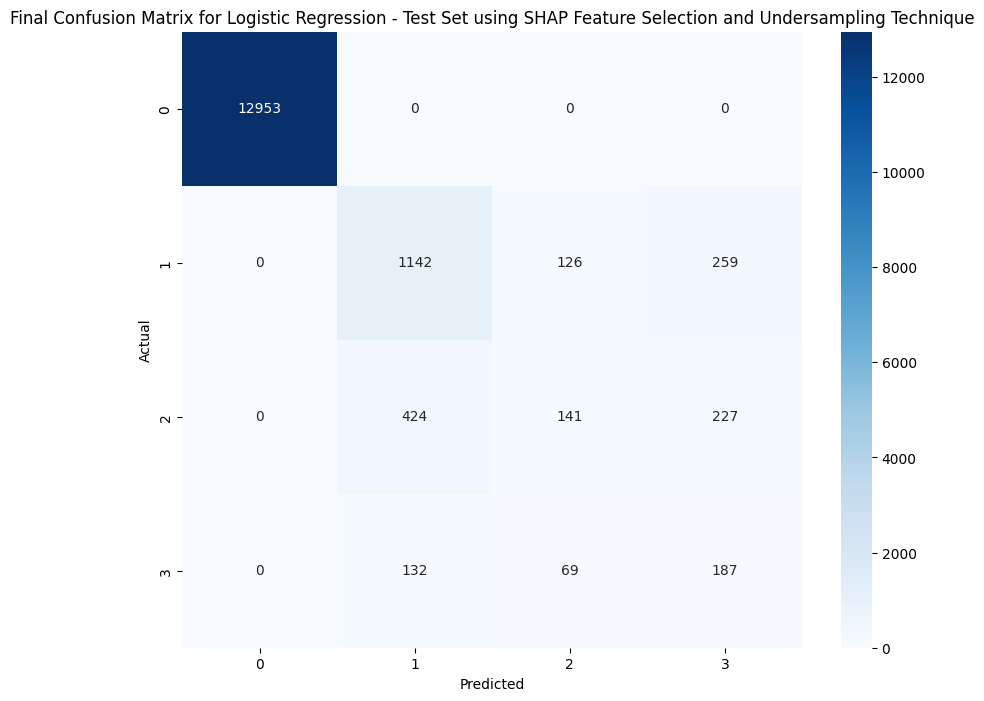

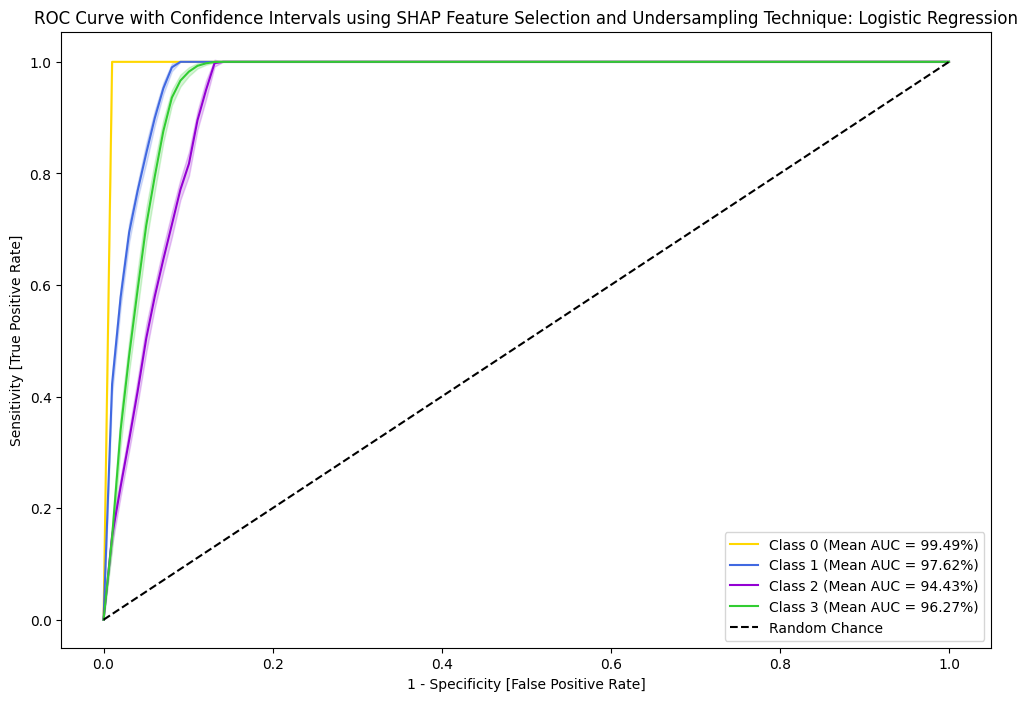


Logistic Regression train and test predictions have been saved separately.


In [58]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
import joblib
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

# Define selected features for each model based on SHAP and SHAP analysis
selected_features_SHAP = [
'Cost_claims_year',
'R_Claims_history',
'N_claims_history',
'Seniority',
'Lapse',
'Driving_experience_years',
'Premium',
'Cylinder_capacity',
'Year_matriculation',
'Weight']

# Separate features and target for training and test sets
X_train_lr = train_resampled_set[selected_features_SHAP]
X_train_gb = train_resampled_set[selected_features_SHAP]
y_train_resampled = train_resampled_set['N_claims_year']

X_test_lr = test_set[selected_features_SHAP]
X_test_gb = test_set[selected_features_SHAP]
y_test = test_set['N_claims_year']

# Updated function with reduced parallelism and folds
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation with reduced parallel jobs and folds
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10, 
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1, 
        random_state=42
    )

    # Outer cross-validation with reduced folds
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the outer fold's training subset
        print("Original class distribution in training fold_shap_undersampling:", Counter(y_train_fold))

        # Inner cross-validation with resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        print(f"  Fold {fold} Accuracy_shap_undersampling: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score_shap_undersampling: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score_shap_undersampling: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold} using SHAP Feature Selection and Undersampling Technique")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}_SHAP_undersampling.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)


    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on test set
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters: {search.best_params_} (SHAP_undersampling)")
    print(f"{model_name} Accuracy on Test Set: {accuracy} (SHAP_undersampling)")
    print(f"{model_name} F1 Score on Test Set: {f1} (SHAP_undersampling)")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc} (SHAP_undersampling)")
    print(f"{model_name} Classification Report:\n{class_report} (SHAP_undersampling)")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set using SHAP Feature Selection and Undersampling Technique")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix_boru_undersampling.png")
    plt.show()

     # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals using SHAP Feature Selection and Undersampling Technique: {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_(SHAP_undersampling).png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_(SHAP_undersampling).csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_(SHAP_undersampling).csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")
    
    # Save model and predictions
    joblib.dump(best_model, f"{model_name}_best_model_(SHAP_undersampling).joblib")
    
    return fold_results, best_model

param_grid_lr_shap = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__max_iter': [100, 200, 500]
}


fold_results_lr_shap, best_model_lr_shap = nested_cv_model(
    LogisticRegression(random_state=42),           # Model for Logistic Regression
    param_grid_lr_shap,                  # Parameter grid for Logistic Regression
    'Logistic Regression',          # Model name
    X_train_lr,                        # Training features
    y_train,                        # Training labels
    X_test_lr,                         # Test features
    y_test                          # Test labels
)


#XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}



Starting Nested Cross-Validation for Gradient Boosting...

Fold 1...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy_shap_undersampling: 0.9321519795657727
  Fold 1 F1 Score_shap_undersampling: 0.9358951395397809
  Fold 1 ROC AUC Score_shap_undersampling: 0.8543957717981633

Fold 2...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy_shap_undersampling: 0.9285600255427842
  Fold 2 F1 Score_shap_undersampling: 0.9324983453037761
  Fold 2 ROC AUC Score_shap_undersampling: 0.8468637516758104

Fold 3...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy_shap_undersampling: 0.9310344827586207
  Fold 3 F1 Score_shap_undersampling: 0.934388863955738
  Fold 3 ROC AUC Score_shap_undersampling: 0.8504611752617

Fold 4...
Original class distribution in traini

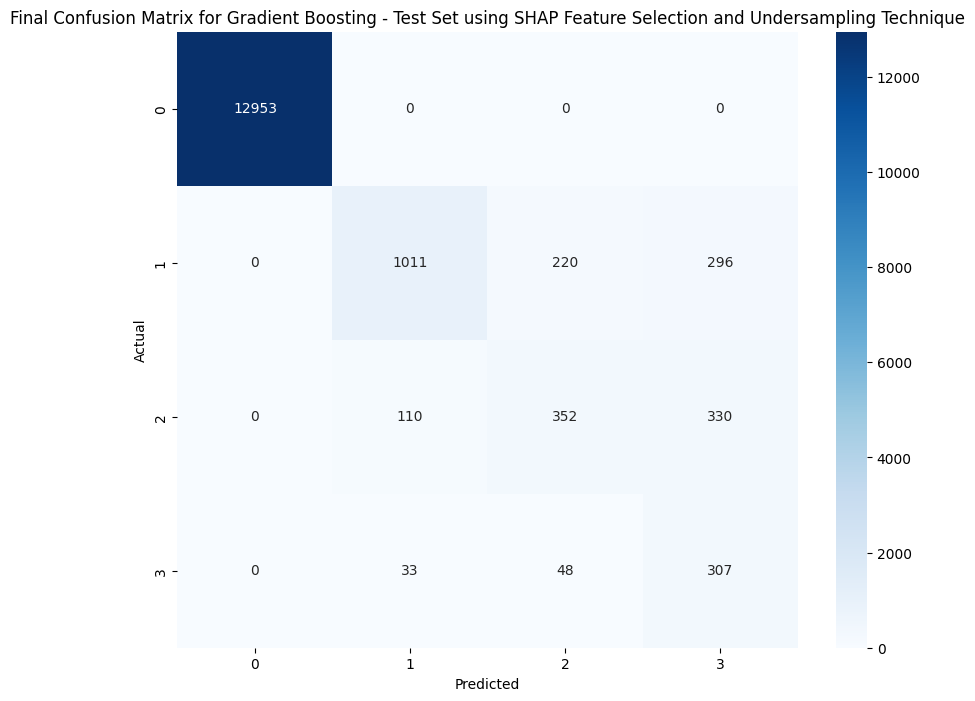

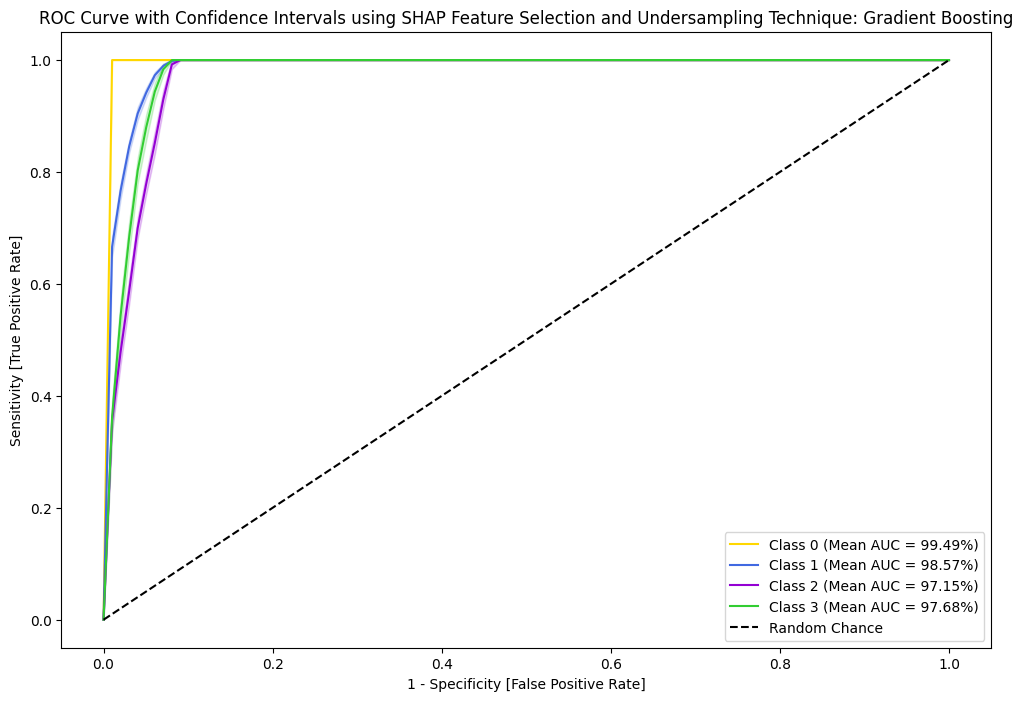


Gradient Boosting train and test predictions have been saved separately.


In [59]:
param_grid_gb_shap = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.6, 0.7, 0.8, 1.0]
}


fold_results_gb_shap, best_model_gb_shap = nested_cv_model(
    GradientBoostingClassifier(random_state=42),  # Model for Gradient Boosting
    param_grid_gb_shap,                 # Parameter grid for Gradient Boosting
    'Gradient Boosting',            # Model name
    X_train_gb,                        # Training features
    y_train,                        # Training labels
    X_test_gb,                         # Test features
    y_test                          # Test labels
)



Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:03:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 1 Accuracy_shap_undersampling: 0.9287994891443168
  Fold 1 F1 Score_shap_undersampling: 0.9330876448627072
  Fold 1 ROC AUC Score_shap_undersampling: 0.8523651519284734

Fold 2...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:03:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 2 Accuracy_shap_undersampling: 0.9288793103448276
  Fold 2 F1 Score_shap_undersampling: 0.9327309529217217
  Fold 2 ROC AUC Score_shap_undersampling: 0.8479589664370577

Fold 3...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy_shap_undersampling: 0.9327851840025545
  Fold 4 F1 Score_shap_undersampling: 0.9365083434229399
  Fold 4 ROC AUC Score_shap_undersampling: 0.8573103528343969

Fold 5...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:04:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy_shap_undersampling: 0.9259998403448552
  Fold 5 F1 Score_shap_undersampling: 0.930253367996426
  Fold 5 ROC AUC Score_shap_undersampling: 0.8448206585578619


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:04:19] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:04:26] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7} (SHAP_undersampling)
XGBoost Accuracy on Test Set: 0.9315453384418901 (SHAP_undersampling)
XGBoost F1 Score on Test Set: 0.935306912275914 (SHAP_undersampling)
XGBoost ROC AUC Score on Test Set: 0.9847162340955908 (SHAP_undersampling)
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.89      0.65      0.75      1527
           2       0.59      0.40      0.48       792
           3       0.31      0.85      0.46       388

    accuracy                           0.93     15660
   macro avg       0.70      0.72      0.67     15660
weighted avg       0.95      0.93      0.94     15660
 (SHAP_undersampling)


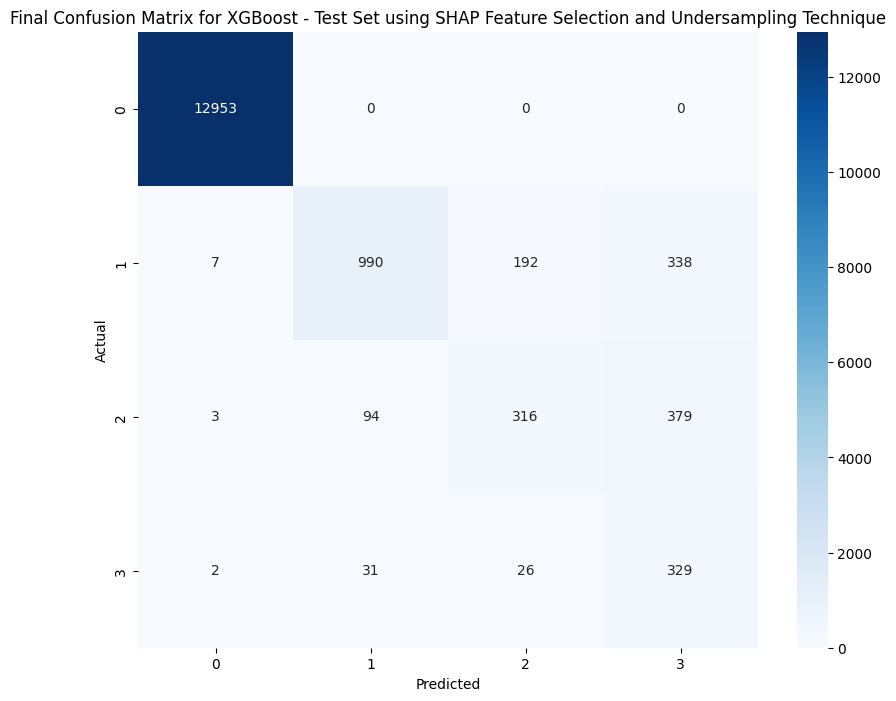

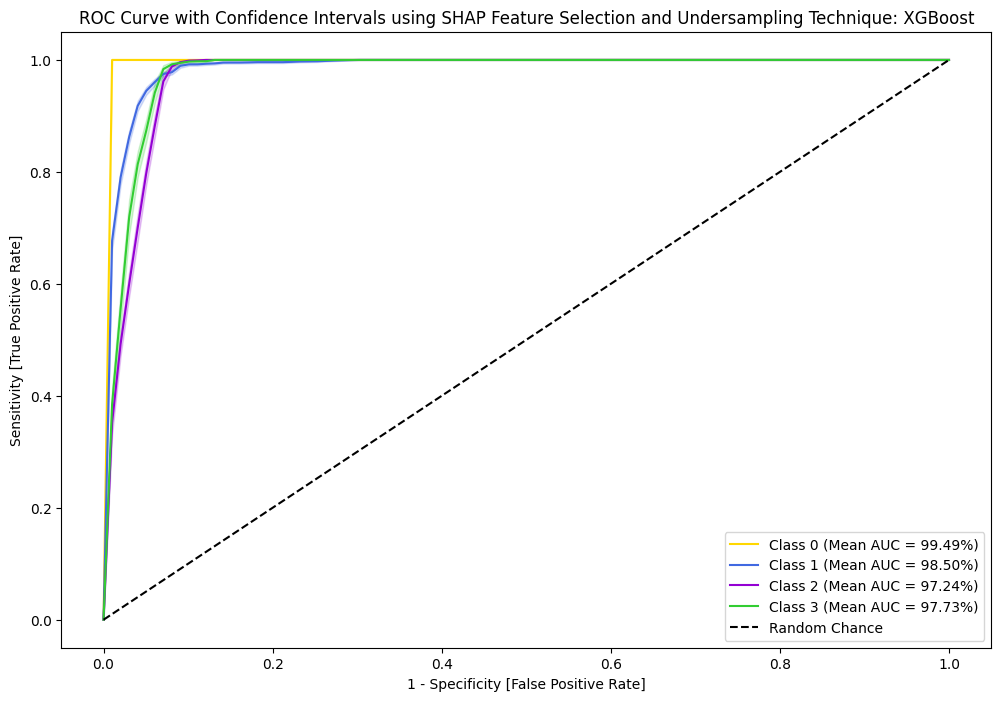


XGBoost train and test predictions have been saved separately.


In [40]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
import joblib
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

# Define selected features for each model based on SHAP and SHAP analysis
selected_features_rf_SHAP = [
'Cost_claims_year',
'N_claims_history',
'R_Claims_history',
'Seniority',
'Lapse',
'Driving_experience_years',
'Premium',
'Payment',
'Value_vehicle',
'Cylinder_capacity']
#selected_features_gb_SHAP = [
#    'Premium', 'Driving_experience_years', 'Cylinder_capacity', 'Weight', 'Power'
#]
selected_features_xgb_SHAP = [
'Cost_claims_year',
'R_Claims_history',
'N_claims_history',
'Seniority',
'Lapse',
'Driving_experience_years',
'Cylinder_capacity',
'Premium',
'Year_matriculation',
'Weight']

# Separate features and target for training and test sets
X_train_rf = train_resampled_set[selected_features_rf_SHAP]
#X_train_gb = train_resampled_set[selected_features_gb_SHAP]
X_train_xgb = train_resampled_set[selected_features_xgb_SHAP]

y_train_resampled = train_resampled_set['N_claims_year']

X_test_rf = test_set[selected_features_rf_SHAP]
#X_test_gb = test_set[selected_features_gb_SHAP]
X_test_xgb = test_set[selected_features_xgb_SHAP]

y_test = test_set['N_claims_year']

# Define parameter grids for each model

param_grid_xgb_SHAP = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Updated function with reduced parallelism and folds
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation with reduced parallel jobs and folds
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10, 
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1, 
        random_state=42
    )

    # Outer cross-validation with reduced folds
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the outer fold's training subset
        print("Original class distribution in training fold_shap_undersampling:", Counter(y_train_fold))

        # Inner cross-validation with resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        print(f"  Fold {fold} Accuracy_shap_undersampling: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score_shap_undersampling: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score_shap_undersampling: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold} using SHAP Feature Selection and Undersampling Technique")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}_SHAP_undersampling.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)


    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on test set
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters: {search.best_params_} (SHAP_undersampling)")
    print(f"{model_name} Accuracy on Test Set: {accuracy} (SHAP_undersampling)")
    print(f"{model_name} F1 Score on Test Set: {f1} (SHAP_undersampling)")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc} (SHAP_undersampling)")
    print(f"{model_name} Classification Report:\n{class_report} (SHAP_undersampling)")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set using SHAP Feature Selection and Undersampling Technique")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix_boru_undersampling.png")
    plt.show()

     # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals using SHAP Feature Selection and Undersampling Technique: {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_(SHAP_undersampling).png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_(SHAP_undersampling).csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_(SHAP_undersampling).csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")
    
    # Save model and predictions
    joblib.dump(best_model, f"{model_name}_best_model_(SHAP_undersampling).joblib")
    
    return fold_results, best_model

# Example call for each model with reduced resource usage
fold_results_xgb_shap, best_model_xgb_shap = nested_cv_model(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid_xgb_SHAP,
    'XGBoost',
    X_train_xgb,
    y_train_resampled,
    X_test_xgb,
    y_test
)


Starting Nested Cross-Validation for Random Forest...

Fold 1...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy_shap_undersampling: 0.9311143039591315
  Fold 1 F1 Score_shap_undersampling: 0.9348317732021255
  Fold 1 ROC AUC Score_shap_undersampling: 0.8493891276895553

Fold 2...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy_shap_undersampling: 0.9268837803320562
  Fold 2 F1 Score_shap_undersampling: 0.9309954640759326
  Fold 2 ROC AUC Score_shap_undersampling: 0.8392066993344464

Fold 3...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy_shap_undersampling: 0.9269636015325671
  Fold 3 F1 Score_shap_undersampling: 0.9308519492144214
  Fold 3 ROC AUC Score_shap_undersampling: 0.8437274982598795

Fold 4...
Original class distribution in traini

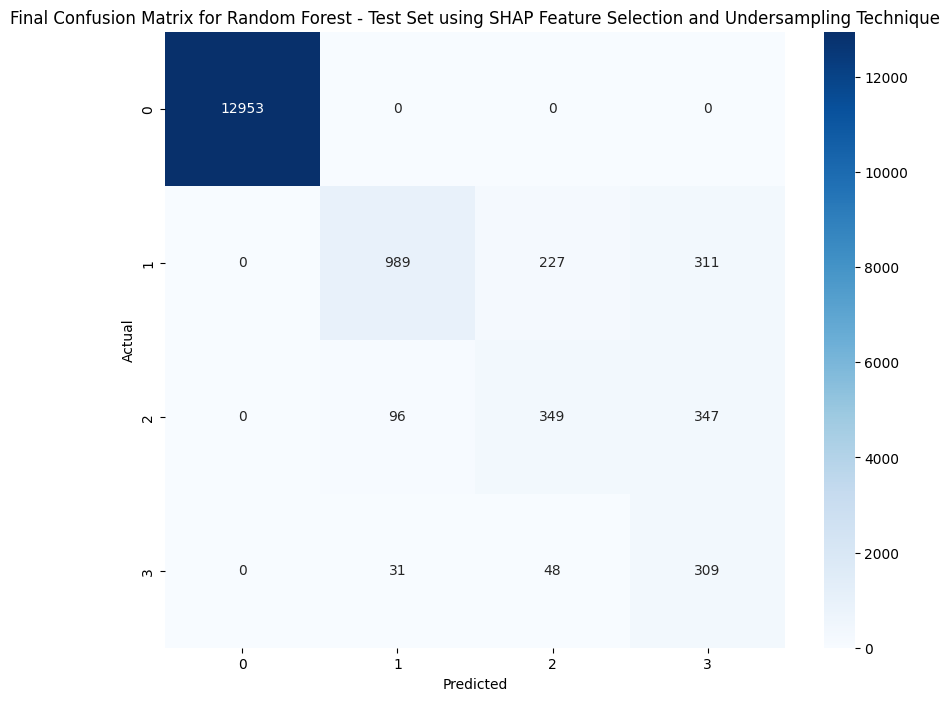

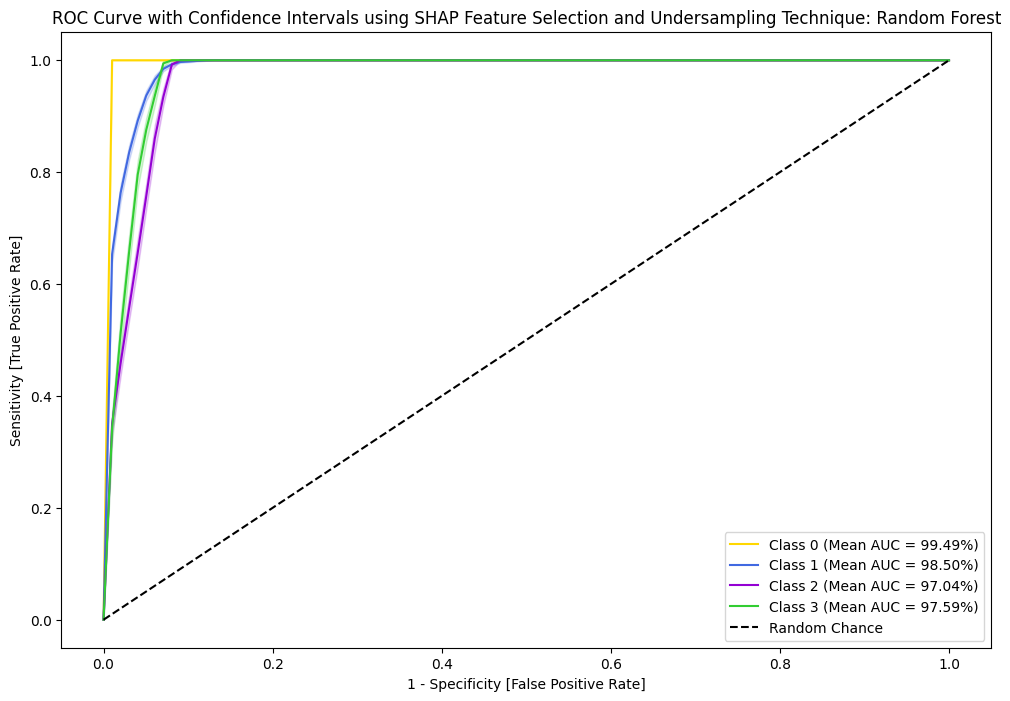


Random Forest train and test predictions have been saved separately.


In [41]:
param_grid_rf = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 6]
}
fold_results_rf_shap, best_model_rf_shap = nested_cv_model(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    'Random Forest',
    X_train_rf,
    y_train_resampled,
    X_test_rf,
    y_test
) #2mins 


Starting Nested Cross-Validation for Gradient Boosting...

Fold 1...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy_shap_undersampling: 0.9321519795657727
  Fold 1 F1 Score_shap_undersampling: 0.9359721270657694
  Fold 1 ROC AUC Score_shap_undersampling: 0.8513941688860432

Fold 2...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy_shap_undersampling: 0.9293582375478927
  Fold 2 F1 Score_shap_undersampling: 0.9331130830157928
  Fold 2 ROC AUC Score_shap_undersampling: 0.8486077251595043

Fold 3...
Original class distribution in training fold_shap_undersampling: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy_shap_undersampling: 0.9300766283524904
  Fold 3 F1 Score_shap_undersampling: 0.9337371532706776
  Fold 3 ROC AUC Score_shap_undersampling: 0.8468165367985595

Fold 4...
Original class distribution in tr

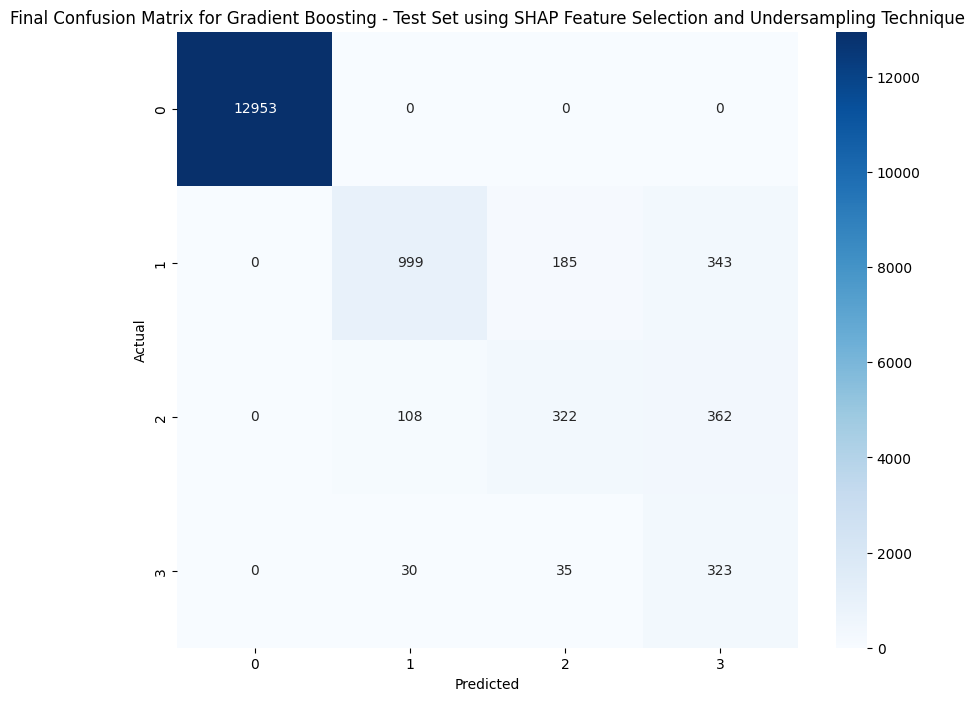

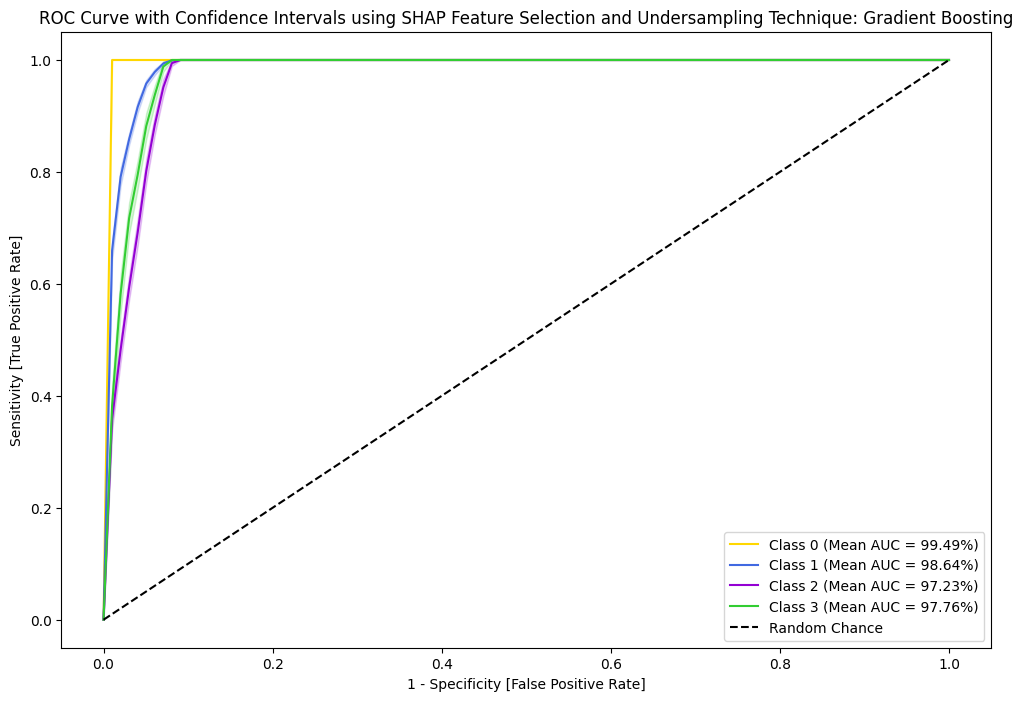


Gradient Boosting train and test predictions have been saved separately.


In [42]:
# 9 mins 
param_grid_gb = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.6, 0.7, 0.8, 1.0]
}


fold_results_gb_shap, best_model_gb_shap = nested_cv_model(
    GradientBoostingClassifier(random_state=42),  # Model for Gradient Boosting
    param_grid_gb,                 # Parameter grid for Gradient Boosting
    'Gradient Boosting',            # Model name
    X_train,                        # Training features
    y_train,                        # Training labels
    X_test,                         # Test features
    y_test                          # Test labels
)

#### Burota
25 mins

In [27]:
#34 mins 
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from boruta import BorutaPy

# Load the datasets
train_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

# Separate features and target
X_train = train_set.drop(columns=['N_claims_year', 'ID'])
y_train = train_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year', 'ID'])
y_test = test_set['N_claims_year']

# ========================
# Boruta Feature Selection with Feature Ranking
# ========================
def boruta_feature_selection(X_train, y_train, model_type="RandomForest"):
    # Define base model with best parameters for Boruta
    if model_type == "RandomForest":
        base_model = RandomForestClassifier(n_estimators=200, min_samples_split=2, min_samples_leaf=6, max_depth=30, random_state=42)
        # Random Forest (pipeline with undersampling): {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 6, 'model__max_depth': 30}
    elif model_type == "GradientBoosting":
        base_model = GradientBoostingClassifier(subsample=0.8, n_estimators=300, max_depth=5, learning_rate=0.01, random_state=42)
        #Gradient Boosting (pipeline with undersampling): {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.01}
    elif model_type == "XGBoost":
        base_model = XGBClassifier(subsample=0.7, n_estimators=200, max_depth=7, learning_rate=0.01, colsample_bytree= 0.7, random_state=42)
        #XGBoost  (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
    else:
        raise ValueError("Invalid model type. Choose either 'RandomForest', or 'XGBoost'")
    



    # Initialize Boruta with the specified model
    boruta_selector = BorutaPy(
        estimator=base_model,
        n_estimators='auto',
        random_state=42,
        verbose=2
    )

    # Fit Boruta selector on the dataset
    boruta_selector.fit(X_train.values, y_train.values)

    # Selected features by Boruta
    selected_features = X_train.columns[boruta_selector.support_].tolist()
    print(f"\nSelected Features by Boruta ({model_type}): {selected_features}")

    # Full ranking of all features
    feature_ranking = pd.DataFrame({
        'Feature': X_train.columns,
        'Ranking': boruta_selector.ranking_
    }).sort_values(by='Ranking')  # Sorting by ranking, 1 is the highest rank

    # Print all feature names and their rankings
    print(f"\nFull Feature Rankings by Boruta ({model_type}):")
    for _, row in feature_ranking.iterrows():
        print(f"Feature: {row['Feature']}, Rank: {row['Ranking']}")

    return X_train[selected_features], selected_features, feature_ranking

# ========================
# Execute Boruta for Each Model and Display Full Feature Rankings
# ========================

# Boruta for Random Forest
print("Executing Boruta for Random Forest...")
X_train_rf, selected_features_rf, rf_feature_ranking = boruta_feature_selection(X_train, y_train, model_type="RandomForest")

# Boruta for Gradient Boosting
print("\nExecuting Boruta for Gradient Boosting...")
X_train_gbm, selected_features_gbm, gbm_feature_ranking = boruta_feature_selection(X_train, y_train, model_type="GradientBoosting")

# Boruta for XGBoost
print("\nExecuting Boruta for XGBoost...")
X_train_xgb, selected_features_xgb, xgb_feature_ranking = boruta_feature_selection(X_train, y_train, model_type="XGBoost")


Executing Boruta for Random Forest...
Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	24
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	5
Tentative: 	1
Rejected: 	18
Iteration: 	9 / 100
Confirmed: 	5
Tentative: 	1
Rejected: 	18
Iteration: 	10 / 100
Confirmed: 	5
Tentative: 	1
Rejected: 	18
Iteration: 	11 / 100
Confirmed: 	5
Tentative: 	1
Rejected: 	18
Iteration: 	12 / 100
Confirmed: 	5
Tentative: 	1
Rejected: 	18
Iteration: 	13 / 100
Confirmed: 	5
Tentative: 	1
Rejected: 	18
Iteration: 	14 / 100
Confirmed: 	5
Tentative: 	1
Rejected: 	18
Iteration: 	15 / 100
Confirmed: 	5
Tentative: 	1
Rejected: 	18
Iteration: 	16 / 100
Confi

In [55]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

# Load the datasets
train_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

# Separate features and target
X_train = train_set.drop(columns=['N_claims_year', 'ID'])
y_train = train_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year', 'ID'])
y_test = test_set['N_claims_year']

# ========================
# Recursive Feature Elimination (RFE) with Logistic Regression
# ========================
def rfe_feature_selection_logistic(X_train, y_train, num_features=10):
    """
    Perform RFE feature selection using Logistic Regression with specified best parameters.

    Parameters:
    - X_train: pd.DataFrame, training features
    - y_train: pd.Series, target variable
    - num_features: int, the number of top features to select

    Returns:
    - pd.DataFrame: Selected features based on RFE
    - list: List of selected feature names
    - pd.DataFrame: Feature ranking for all features
    """
    # Initialize Logistic Regression model with best parameters
    base_model = LogisticRegression(
        solver='liblinear', 
        max_iter=100, 
        C=0.01, 
        random_state=42
    )

    # Initialize RFE with Logistic Regression
    rfe_selector = RFE(
        estimator=base_model,
        n_features_to_select=num_features,
        step=1,
        verbose=2
    )

    # Fit RFE selector on the dataset
    rfe_selector.fit(X_train, y_train)

    # Selected features by RFE
    selected_features = X_train.columns[rfe_selector.support_].tolist()
    print(f"\nSelected Features by RFE (Logistic Regression): {selected_features}")

    # Full ranking of all features
    feature_ranking = pd.DataFrame({
        'Feature': X_train.columns,
        'Ranking': rfe_selector.ranking_
    }).sort_values(by='Ranking')  # Sorting by ranking, 1 is the highest rank

    # Print all feature names and their rankings
    print("\nFull Feature Rankings by RFE (Logistic Regression):")
    for _, row in feature_ranking.iterrows():
        print(f"Feature: {row['Feature']}, Rank: {row['Ranking']}")

    return X_train[selected_features], selected_features, feature_ranking

# ========================
# Execute RFE for Logistic Regression and Display Feature Rankings
# ========================

print("Executing RFE for Logistic Regression...")
X_train_logistic, selected_features_logistic, logistic_feature_ranking = rfe_feature_selection_logistic(X_train, y_train, num_features=10)

# Display results
print("\nLogistic Regression Selected Features:", selected_features_logistic)
print("\nLogistic Regression Full Feature Rankings:\n", logistic_feature_ranking)


Executing RFE for Logistic Regression...
Fitting estimator with 24 features.
Fitting estimator with 23 features.
Fitting estimator with 22 features.
Fitting estimator with 21 features.
Fitting estimator with 20 features.
Fitting estimator with 19 features.
Fitting estimator with 18 features.
Fitting estimator with 17 features.
Fitting estimator with 16 features.
Fitting estimator with 15 features.
Fitting estimator with 14 features.
Fitting estimator with 13 features.
Fitting estimator with 12 features.
Fitting estimator with 11 features.

Selected Features by RFE (Logistic Regression): ['Lapse', 'Cost_claims_year', 'R_Claims_history', 'N_doors', 'Driving_experience_years', 'Age_Group_16-24', 'Age_Group_25-39', 'Age_Group_40-64', 'Type_fuel_D', 'Type_fuel_P']

Full Feature Rankings by RFE (Logistic Regression):
Feature: Type_fuel_P, Rank: 1
Feature: Lapse, Rank: 1
Feature: Age_Group_40-64, Rank: 1
Feature: Cost_claims_year, Rank: 1
Feature: R_Claims_history, Rank: 1
Feature: Age_Group_

#### Burota feature selection


Starting Nested Cross-Validation for Logistic Regression...

Fold 1...
Original class distribution in training fold_shap_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy_shap_Boruta: 0.9173052362707536
  Fold 1 F1 Score_shap_Boruta: 0.9154655006222966
  Fold 1 ROC AUC Score_shap_Boruta: 0.7801876635389946

Fold 2...
Original class distribution in training fold_shap_Boruta: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


  Fold 2 Accuracy_shap_Boruta: 0.9185025542784163
  Fold 2 F1 Score_shap_Boruta: 0.9169656704916483
  Fold 2 ROC AUC Score_shap_Boruta: 0.7840566163369309

Fold 3...
Original class distribution in training fold_shap_Boruta: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy_shap_Boruta: 0.9169061302681992
  Fold 3 F1 Score_shap_Boruta: 0.9148952547157698
  Fold 3 ROC AUC Score_shap_Boruta: 0.783013479655402

Fold 4...
Original class distribution in training fold_shap_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy_shap_Boruta: 0.914504669912988
  Fold 4 F1 Score_shap_Boruta: 0.9131910769001703
  Fold 4 ROC AUC Score_shap_Boruta: 0.7765186701029921

Fold 5...
Original class distribution in training fold_shap_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 5 Accuracy_shap_Boruta: 0.9125089806018999
  Fold 5 F1 Score_shap_Boruta: 0.912288045934057
  Fold 5 ROC AUC Score_shap_Boruta: 0.7763713926274232

Logistic Regression Best Parameter

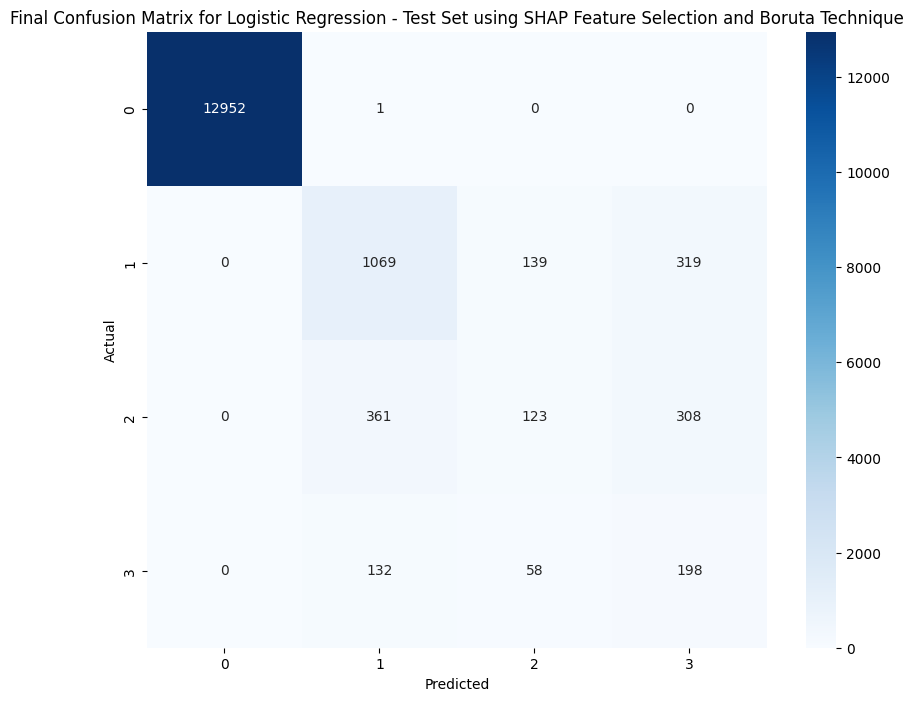

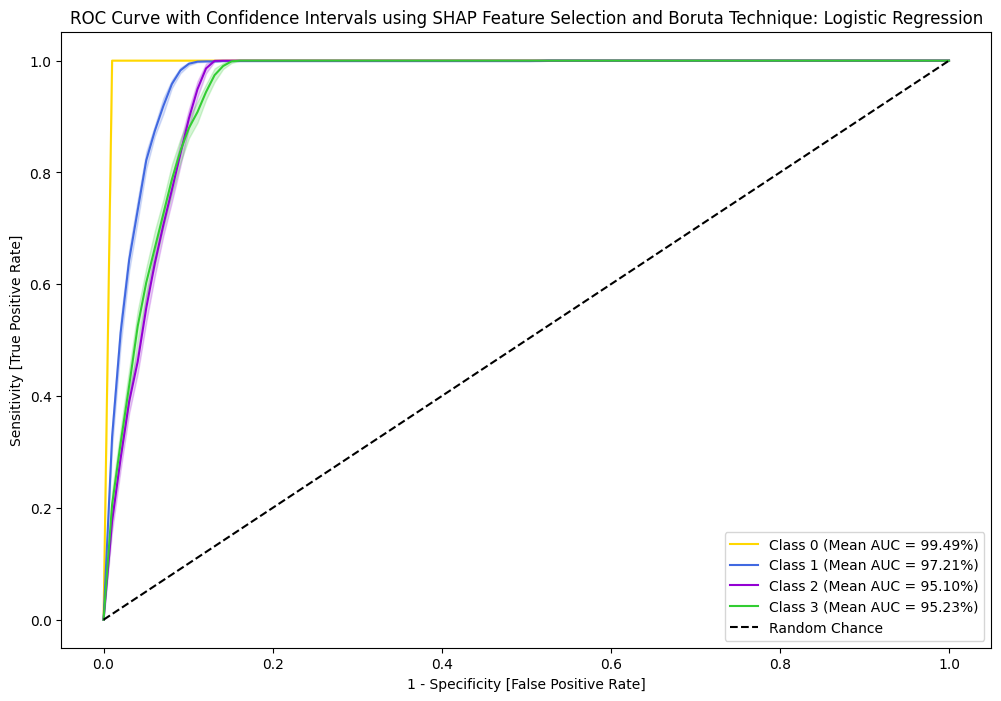


Logistic Regression train and test predictions have been saved separately.


In [60]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
import joblib
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

selected_features_lr_Bu = [
'Type_fuel_P',
'Lapse',
'Age_Group_40-64',
'Cost_claims_year',
'R_Claims_history',
'Age_Group_25-39',
'Age_Group_16-24',
'Driving_experience_years',
'Type_fuel_D',
'N_doors']


# Separate features and target for training and test sets
X_train_lr = train_resampled_set[selected_features_lr_Bu]
y_train_resampled = train_resampled_set['N_claims_year']

X_test_lr = test_set[selected_features_lr_Bu]
y_test = test_set['N_claims_year']


# Updated function with reduced parallelism and folds
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with Boruta and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation with reduced parallel jobs and folds
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,  
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,  
        random_state=42
    )

    # Outer cross-validation with reduced folds
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Reduced to 3 folds

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the outer fold's training subset
        print("Original class distribution in training fold_shap_Boruta:", Counter(y_train_fold))

        # Inner cross-validation with resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        print(f"  Fold {fold} Accuracy_shap_Boruta: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score_shap_Boruta: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score_shap_Boruta: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold} using SHAP Feature Selection and Boruta Technique")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}_SHAP_Boruta.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)


    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on test set
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters: {search.best_params_} (SHAP_Boruta)")
    print(f"{model_name} Accuracy on Test Set: {accuracy} (SHAP_Boruta)")
    print(f"{model_name} F1 Score on Test Set: {f1} (SHAP_Boruta)")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc} (SHAP_Boruta)")
    print(f"{model_name} Classification Report:\n{class_report} (SHAP_Boruta)")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set using SHAP Feature Selection and Boruta Technique")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix_boru_Boruta.png")
    plt.show()

     # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals using SHAP Feature Selection and Boruta Technique: {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_(SHAP_Boruta).png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_(SHAP_Boruta).csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_(SHAP_Boruta).csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")
    
    # Save model and predictions
    joblib.dump(best_model, f"{model_name}_best_model_(SHAP_Boruta).joblib")
    
    return fold_results, best_model

param_grid_lr_bu = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__solver': ['liblinear', 'lbfgs'],
    'model__max_iter': [100, 200, 500]
}
fold_results_lr_bu, best_model_lr_bu = nested_cv_model(
    LogisticRegression(random_state=42),           # Model for Logistic Regression
    param_grid_lr_bu,                              # Parameter grid for Logistic Regression
    'Logistic Regression',                         # Model name
    X_train_lr,                                    # Training features filtered by selected_features_lr_Bu
    y_train_resampled,                             # Training labels
    X_test_lr,                                     # Test features filtered by selected_features_lr_Bu
    y_test                                         # Test labels
)


Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
1 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\sklearn\base.py", line 1152, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Prapatsorn\miniconda3\Lib\site-packages\imblearn\pipeline.py", line 326, in fit
    se

  Fold 1 Accuracy_Bu_Boruta: 0.9327107279693486
  Fold 1 F1 Score_Bu_Boruta: 0.9362161732916813
  Fold 1 ROC AUC Score_Bu_Boruta: 0.8539998297844138

Fold 2...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:25:07] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 2 Accuracy_Bu_Boruta: 0.9273627075351213
  Fold 2 F1 Score_Bu_Boruta: 0.9311836242430684
  Fold 2 ROC AUC Score_Bu_Boruta: 0.8320492317856836

Fold 3...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy_Bu_Boruta: 0.9349405284585296
  Fold 4 F1 Score_Bu_Boruta: 0.9387769183213138
  Fold 4 ROC AUC Score_Bu_Boruta: 0.8595004624532983

Fold 5...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:25:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy_Bu_Boruta: 0.9268779436417338
  Fold 5 F1 Score_Bu_Boruta: 0.9313110920004123
  Fold 5 ROC AUC Score_Bu_Boruta: 0.8448569094521616


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:25:28] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:25:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7} (Bu_Boruta)
XGBoost Accuracy on Test Set: 0.9321839080459771 (Bu_Boruta)
XGBoost F1 Score on Test Set: 0.9359954281012877 (Bu_Boruta)
XGBoost ROC AUC Score on Test Set: 0.9843873330806107 (Bu_Boruta)
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.89      0.65      0.75      1527
           2       0.58      0.41      0.48       792
           3       0.32      0.83      0.46       388

    accuracy                           0.93     15660
   macro avg       0.70      0.72      0.67     15660
weighted avg       0.95      0.93      0.94     15660
 (Bu_Boruta)


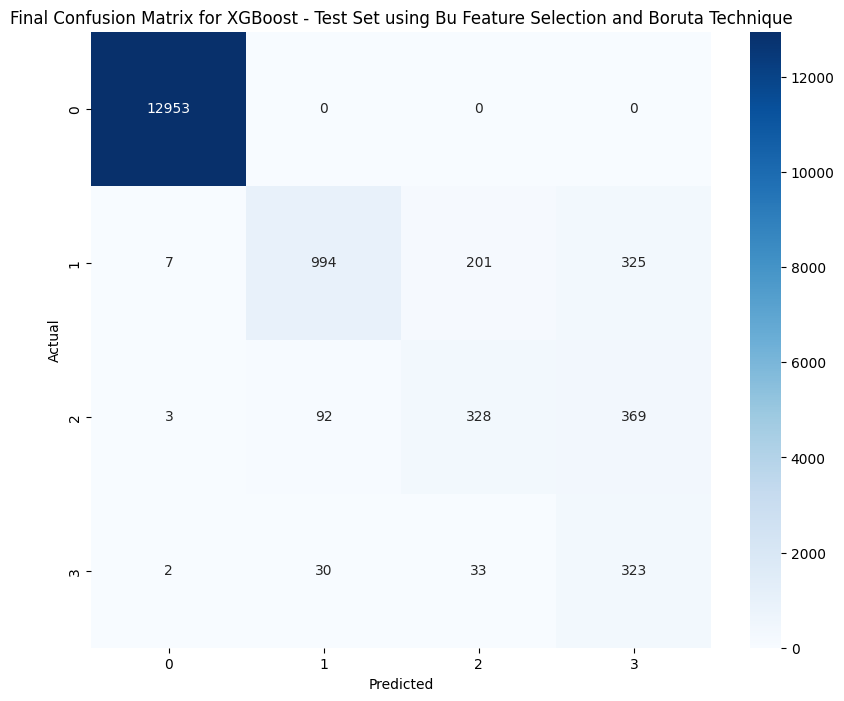

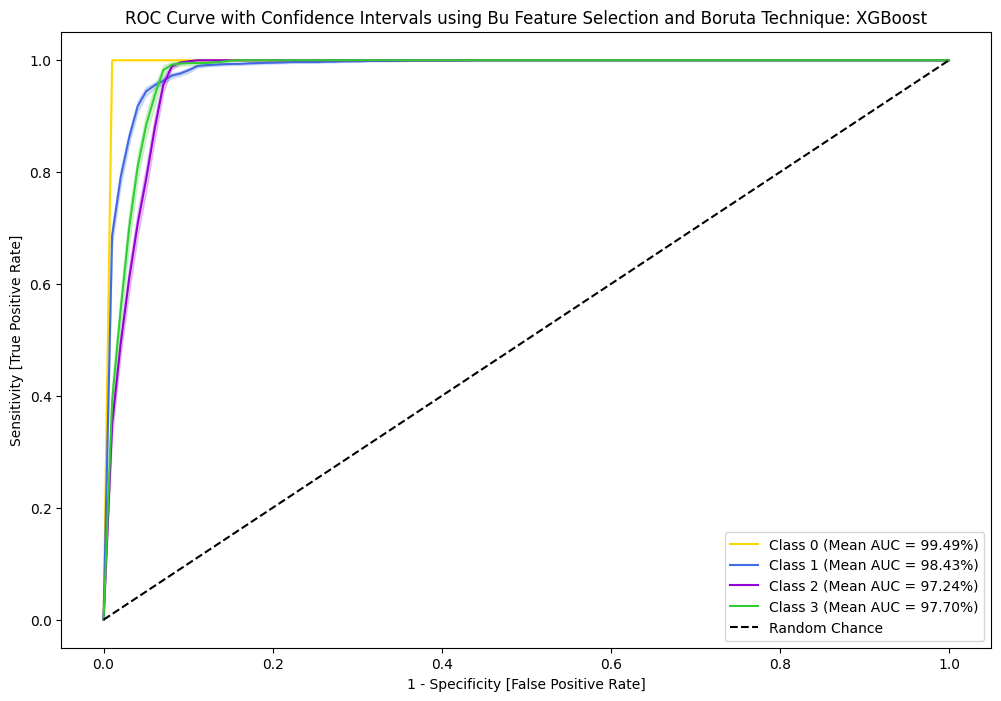


XGBoost train and test predictions have been saved separately.


In [61]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_val_score
import joblib
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

selected_features_rf_Bu = [
'Year_matriculation',
'Seniority',
'Premium',
'Cost_claims_year',
'N_claims_history',
'R_Claims_history',
'Lapse',
'Value_vehicle',
'Driving_experience_years',
'Power']

selected_features_gb_Bu = [
'Year_matriculation',
'Seniority',
'Premium',
'Cost_claims_year',
'N_claims_history',
'R_Claims_history',
'Lapse',
'Value_vehicle',
'Driving_experience_years',
'Power']
selected_features_xgb_Bu = [
'Distribution_channel',
'Driving_experience_years',
'Second_driver',
'R_Claims_history',
'N_claims_history',
'Year_matriculation',
'Premium',
'Payment',
'Seniority',
'Cost_claims_year']

# Separate features and target for training and test sets
X_train_rf = train_resampled_set[selected_features_rf_Bu]
X_train_gb = train_resampled_set[selected_features_gb_Bu]
X_train_xgb = train_resampled_set[selected_features_xgb_Bu]

y_train_resampled = train_resampled_set['N_claims_year']

X_test_rf = test_set[selected_features_rf_Bu]
X_test_gb = test_set[selected_features_gb_Bu]
X_test_xgb = test_set[selected_features_xgb_Bu]

y_test = test_set['N_claims_year']

# Define parameter grids for each model

param_grid_xgb_Bu = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}
# Updated function with reduced parallelism and folds
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with Boruta and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation with reduced parallel jobs and folds
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,  
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,  
        random_state=42
    )

    # Outer cross-validation with reduced folds
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # Reduced to 3 folds

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the outer fold's training subset
        print("Original class distribution in training fold_Bu_Boruta:", Counter(y_train_fold))

        # Inner cross-validation with resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        print(f"  Fold {fold} Accuracy_Bu_Boruta: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score_Bu_Boruta: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score_Bu_Boruta: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold} using Bu Feature Selection and Boruta Technique")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}_Bu_Boruta.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)


    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on test set
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters: {search.best_params_} (Bu_Boruta)")
    print(f"{model_name} Accuracy on Test Set: {accuracy} (Bu_Boruta)")
    print(f"{model_name} F1 Score on Test Set: {f1} (Bu_Boruta)")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc} (Bu_Boruta)")
    print(f"{model_name} Classification Report:\n{class_report} (Bu_Boruta)")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set using Bu Feature Selection and Boruta Technique")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix_boru_Boruta.png")
    plt.show()

     # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals using Bu Feature Selection and Boruta Technique: {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_(Bu_Boruta).png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_(Bu_Boruta).csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_(Bu_Boruta).csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")
    
    # Save model and predictions
    joblib.dump(best_model, f"{model_name}_best_model_(Bu_Boruta).joblib")
    
    return fold_results, best_model

# Example call for each model with reduced resource usage
fold_results_xgb_boruta, best_model_xgb_boruta = nested_cv_model(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_grid_xgb_Bu,
    'XGBoost',
    X_train_xgb,
    y_train_resampled,
    X_test_xgb,
    y_test
)


Starting Nested Cross-Validation for Random Forest...

Fold 1...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy_Bu_Boruta: 0.9299968071519795
  Fold 1 F1 Score_Bu_Boruta: 0.9337797211939455
  Fold 1 ROC AUC Score_Bu_Boruta: 0.8469115556600647

Fold 2...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy_Bu_Boruta: 0.9281609195402298
  Fold 2 F1 Score_Bu_Boruta: 0.9322166435503267
  Fold 2 ROC AUC Score_Bu_Boruta: 0.8456905696433873

Fold 3...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy_Bu_Boruta: 0.9263250319284803
  Fold 3 F1 Score_Bu_Boruta: 0.930591943788143
  Fold 3 ROC AUC Score_Bu_Boruta: 0.8416138379998825

Fold 4...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy_Bu_Boruta: 0.931827253133

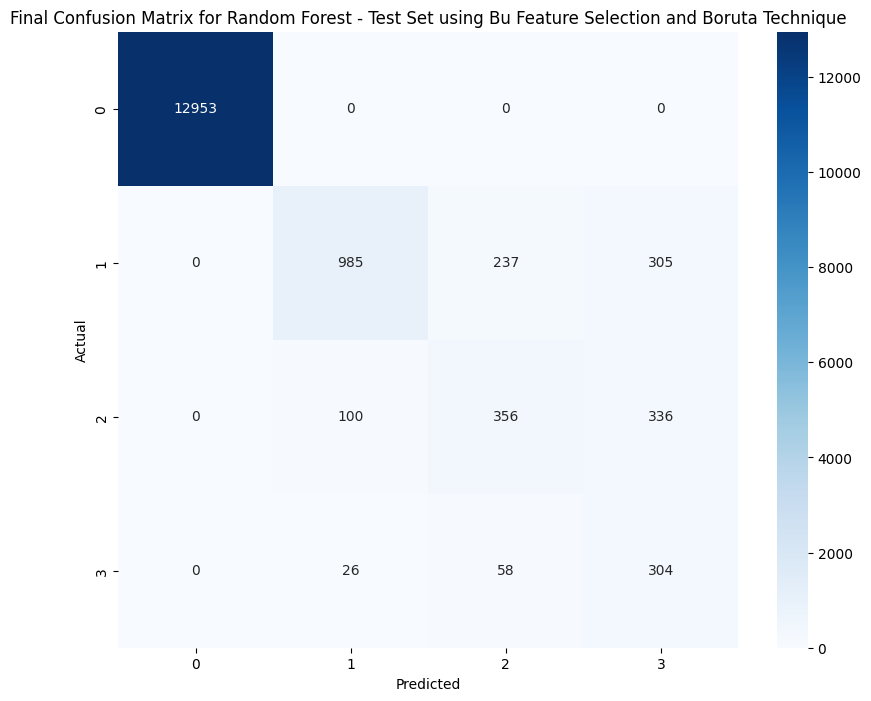

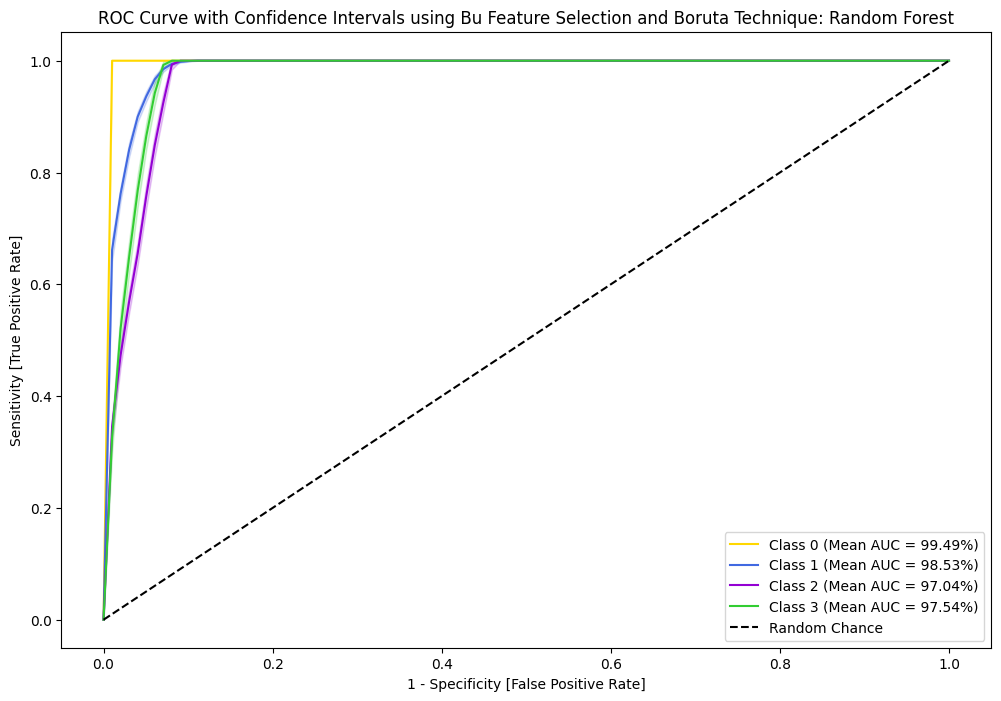


Random Forest train and test predictions have been saved separately.


In [62]:
param_grid_rf = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10, 15],
    'model__min_samples_leaf': [1, 2, 4, 6]
}
fold_results_rf_boruta, best_model_rf_boruta = nested_cv_model(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    'Random Forest',
    X_train_rf,
    y_train_resampled,
    X_test_rf,
    y_test
) #2mins 


Starting Nested Cross-Validation for Gradient Boosting...

Fold 1...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})
  Fold 1 Accuracy_Bu_Boruta: 0.932551085568327
  Fold 1 F1 Score_Bu_Boruta: 0.9363968200640415
  Fold 1 ROC AUC Score_Bu_Boruta: 0.8539358316291746

Fold 2...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 2 Accuracy_Bu_Boruta: 0.9288793103448276
  Fold 2 F1 Score_Bu_Boruta: 0.9326063454655712
  Fold 2 ROC AUC Score_Bu_Boruta: 0.8473434910612139

Fold 3...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})
  Fold 3 Accuracy_Bu_Boruta: 0.9281609195402298
  Fold 3 F1 Score_Bu_Boruta: 0.9323463707203477
  Fold 3 ROC AUC Score_Bu_Boruta: 0.8460141750165374

Fold 4...
Original class distribution in training fold_Bu_Boruta: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})
  Fold 4 Accuracy_Bu_Boruta: 0.93262552

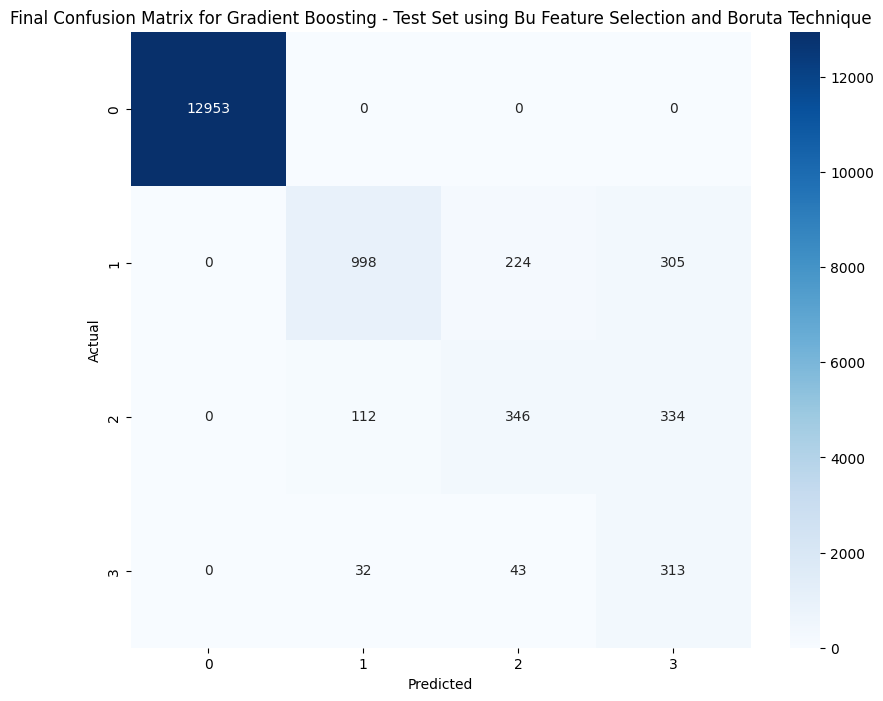

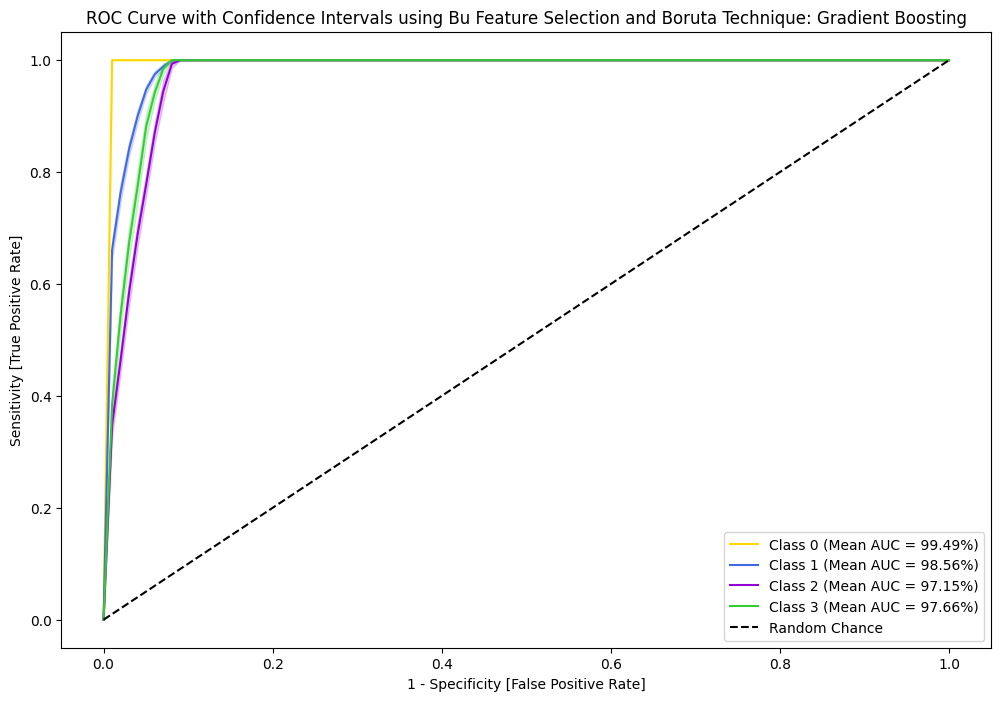


Gradient Boosting train and test predictions have been saved separately.


In [ ]:
param_grid_gb = {
    'model__n_estimators': [50, 100, 200, 300],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.6, 0.7, 0.8, 1.0]
}

# 12 mins
fold_results_gb_boruta, best_model_gb_boruta = nested_cv_model(
    GradientBoostingClassifier(random_state=42),  # Model for Gradient Boosting
    param_grid_gb,                 # Parameter grid for Gradient Boosting
    'Gradient Boosting',            # Model name
    X_train_gb,                        # Training features
    y_train_resampled,                        # Training labels
    X_test_gb,                         # Test features
    y_test                          # Test labels
)



Starting Nested Cross-Validation for XGBoost...

Fold 1...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1240})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:50:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 1 Accuracy: 0.929757343550447
  Fold 1 F1 Score: 0.933893927371715
  Fold 1 ROC AUC Score: 0.8529712532618607

Fold 2...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:50:22] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 2 Accuracy: 0.9293582375478927
  Fold 2 F1 Score: 0.9330566843205442
  Fold 2 ROC AUC Score: 0.8484416164276081

Fold 3...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2533, 3: 1241})


...

  Fold 4 Accuracy: 0.9332641494372156
  Fold 4 F1 Score: 0.9368522269075508
  Fold 4 ROC AUC Score: 0.8555083944159111

Fold 5...
Original class distribution in training fold: Counter({0: 41448, 1: 4888, 2: 2534, 3: 1241})


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:50:41] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


  Fold 5 Accuracy: 0.9259998403448552
  Fold 5 F1 Score: 0.9302400667946233
  Fold 5 ROC AUC Score: 0.8448990589090122


c:\Users\Prapatsorn\miniconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [18:50:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



XGBoost Best Parameters (pipeline with undersampling): {'model__subsample': 0.7, 'model__n_estimators': 200, 'model__max_depth': 7, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}
XGBoost Accuracy on Test Set: 0.9323754789272031
XGBoost F1 Score on Test Set: 0.9360027744613607
XGBoost ROC AUC Score on Test Set: 0.9847353380562471
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12953
           1       0.89      0.66      0.75      1527
           2       0.59      0.40      0.48       792
           3       0.32      0.85      0.46       388

    accuracy                           0.93     15660
   macro avg       0.70      0.73      0.67     15660
weighted avg       0.95      0.93      0.94     15660



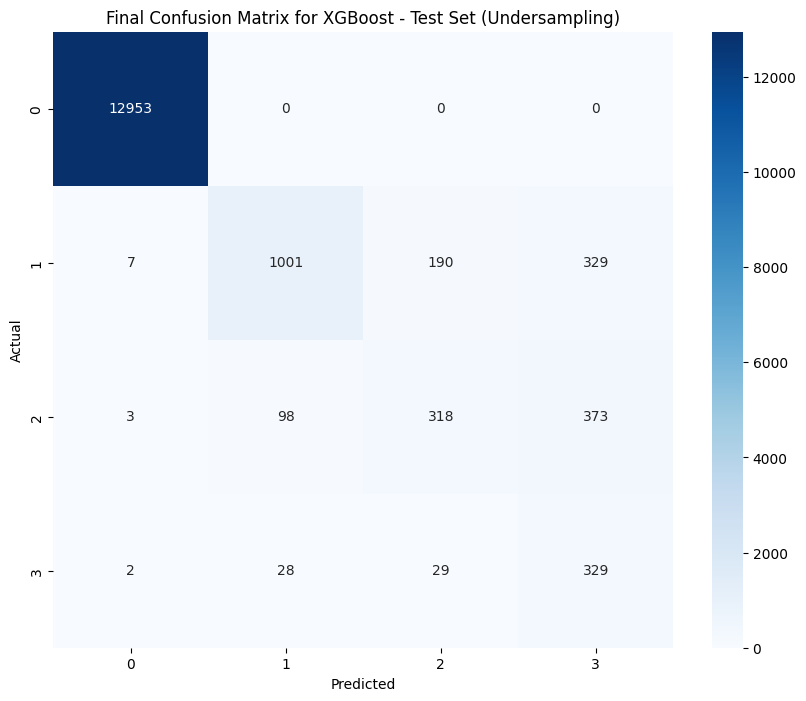

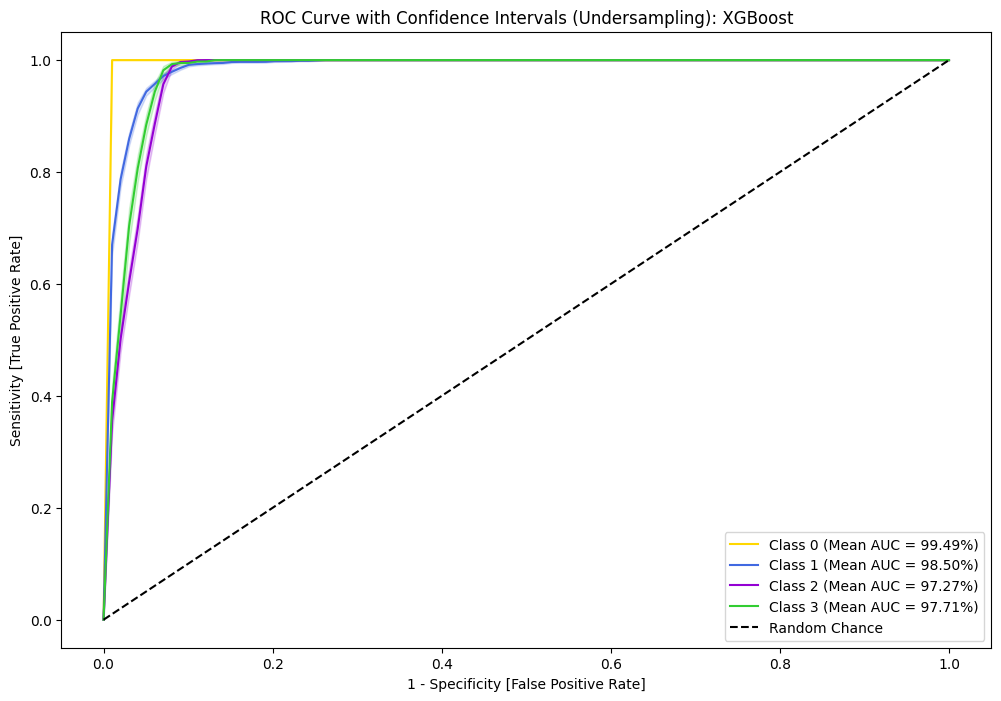


XGBoost train and test predictions have been saved separately.


In [9]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from imblearn.pipeline import Pipeline  # Import the pipeline from imbalanced-learn
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Load data
train_resampled_set = pd.read_csv('train_set.csv')
test_set = pd.read_csv('test_set.csv')

X_train = train_resampled_set.drop(columns=['N_claims_year'])
y_train = train_resampled_set['N_claims_year']
X_test = test_set.drop(columns=['N_claims_year'])
y_test = test_set['N_claims_year']

# Define parameter grids for each model
param_grid_xgb = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

# Updated function with pipeline for undersampling
def nested_cv_model(model, param_grid, model_name, X_train, y_train, X_test, y_test):
    print(f"\nStarting Nested Cross-Validation for {model_name}...")

    # Define the pipeline with undersampling and the model
    pipeline = Pipeline([
        ('under', RandomUnderSampler(random_state=42)),
        ('model', model)
    ])

    # Inner cross-validation for hyperparameter tuning using the pipeline
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring={'accuracy': 'accuracy', 'f1_weighted': 'f1_weighted'},
        refit='accuracy',
        cv=inner_cv,
        n_jobs=-1,
        random_state=42
    )

    # Outer cross-validation for model evaluation
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Collect scores for each fold
    fold_results = []
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X_train, y_train), start=1):
        print(f"\nFold {fold}...")

        # Split data for this fold
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

        # Print class distribution in the original outer fold's training subset before resampling
        print("Original class distribution in training fold:", Counter(y_train_fold))

        # Inner cross-validation with hyperparameter tuning and resampling handled by the pipeline
        search.fit(X_train_fold, y_train_fold)

        # Evaluate on the outer test fold
        y_pred_fold = search.predict(X_test_fold)
        accuracy_fold = accuracy_score(y_test_fold, y_pred_fold)
        f1_fold = f1_score(y_test_fold, y_pred_fold, average='weighted')
        roc_auc_fold = roc_auc_score(pd.get_dummies(y_test_fold), pd.get_dummies(y_pred_fold), average='macro', multi_class='ovr')

        # Print fold results
        print(f"  Fold {fold} Accuracy: {accuracy_fold}")
        print(f"  Fold {fold} F1 Score: {f1_fold}")
        print(f"  Fold {fold} ROC AUC Score: {roc_auc_fold}")

        fold_results.append((fold, accuracy_fold, f1_fold, roc_auc_fold))

        # Plot confusion matrix for each fold
        conf_matrix = confusion_matrix(y_test_fold, y_pred_fold)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix for {model_name} - Fold {fold}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.savefig(f"{model_name}_conf_matrix_fold_{fold}.png")
        plt.close()

    # Train the best model on the entire training set
    search.fit(X_train, y_train)
    best_model = search.best_estimator_

    # Predictions on training and test sets
    y_pred_train = best_model.predict(X_train)
    y_pred_test = best_model.predict(X_test)
    y_pred_probabilities = best_model.predict_proba(X_test)

    # Evaluation metrics on test set
    accuracy = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    roc_auc = roc_auc_score(pd.get_dummies(y_test), y_pred_probabilities, average='macro', multi_class='ovr')

    class_report = classification_report(y_test, y_pred_test)
    conf_matrix = confusion_matrix(y_test, y_pred_test)

    # Display results
    print(f"\n{model_name} Best Parameters (pipeline with undersampling): {search.best_params_}")
    print(f"{model_name} Accuracy on Test Set: {accuracy}")
    print(f"{model_name} F1 Score on Test Set: {f1}")
    print(f"{model_name} ROC AUC Score on Test Set: {roc_auc}")
    print(f"{model_name} Classification Report:\n{class_report}")

    # Plot final confusion matrix for the test set
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Final Confusion Matrix for {model_name} - Test Set (Undersampling)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.savefig(f"{model_name}_final_conf_matrix.png")
    plt.show()

    # Updated ROC curve plotting with bootstrapped confidence intervals
    plt.figure(figsize=(12, 8))
    colors = ['gold', 'royalblue', 'darkviolet', 'limegreen']

    y_test_dummies = pd.get_dummies(y_test)
    bootstraps = 1000  # Number of bootstrap samples
    mean_fpr = np.linspace(0, 1, 100)

    for i, class_label in enumerate(np.unique(y_test)):
        tprs = []

        for _ in range(bootstraps):
            indices = np.random.randint(0, len(y_test), len(y_test))
            y_true_bootstrap = y_test_dummies.iloc[indices, i]
            y_pred_bootstrap = y_pred_probabilities[indices, i]
            fpr, tpr, _ = roc_curve(y_true_bootstrap, y_pred_bootstrap)
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

        mean_tpr = np.mean(tprs, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = auc(mean_fpr, mean_tpr)
        std_tpr = np.std(tprs, axis=0)

        plt.plot(mean_fpr, mean_tpr, color=colors[i % len(colors)], label=f'Class {class_label} (Mean AUC = {mean_auc:.2%})')
        plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr, color=colors[i % len(colors)], alpha=0.2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
    plt.title(f"ROC Curve with Confidence Intervals (Undersampling): {model_name}")
    plt.xlabel("1 - Specificity [False Positive Rate]")
    plt.ylabel("Sensitivity [True Positive Rate]")
    plt.legend(loc='lower right')
    plt.savefig(f"{model_name}_roc_curve_with_ci_undersampling.png")
    plt.show()

    # Export separate CSVs for train and test set predictions
    train_df = X_train.copy()
    train_df['y_true_train'] = y_train
    train_df['y_pred_train'] = y_pred_train

    test_df = X_test.copy()
    test_df['y_true_test'] = y_test
    test_df['y_pred_test'] = y_pred_test

    train_df.to_csv(f"{model_name.lower().replace(' ', '_')}_train_usethisone.csv", index=False)
    test_df.to_csv(f"{model_name.lower().replace(' ', '_')}_test_usethisone.csv", index=False)
    print(f"\n{model_name} train and test predictions have been saved separately.")

    # Save the model
    joblib.dump(best_model, f"{model_name}_best_model.joblib")

    return fold_results, best_model

# Run the nested CV with the XGBoost model as an example
fold_results_xgb, best_model_xgb = nested_cv_model(XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42), param_grid_xgb, 'XGBoost', X_train, y_train, X_test, y_test)
